# Dataset 1

## Step 1: Import thư viện và đọc dữ liệu thô

In [104]:
# ============================================================
# Step 1: Import thư viện và đọc dữ liệu thô
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, precision_recall_curve, auc, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import joblib

try:
    import caas_jupyter_tools as cjt
    display_tables = True
except Exception:
    display_tables = False

## Step 2: EDA và xử lý outliers

In [105]:
# ============================================================
# Step 2: EDA và xử lý outliers
# ============================================================

DATA_DIR = Path("data")
DS1_PATH = DATA_DIR / "heart.csv"
DS2_PATH = DATA_DIR / "heart_failure_clinical_records_dataset.csv"
OUT_DIR = DATA_DIR / "output_figs"
MODEL_DIR = DATA_DIR / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df1 = pd.read_csv(DS1_PATH)
df2 = pd.read_csv(DS2_PATH)

print("Dataset1 shape:", df1.shape)
print("Dataset2 shape:", df2.shape)

def show_df(name, df):
    if display_tables:
        cjt.display_dataframe_to_user(name, df.head(10))
    else:
        print(f"Preview {name}:")
        print(df.head(3).to_string(index=False))

show_df("Dataset1_preview", df1)
show_df("Dataset2_preview", df2)

Dataset1 shape: (918, 12)
Dataset2 shape: (299, 13)
Preview Dataset1_preview:
 Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
  40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
  49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
  37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
Preview Dataset2_preview:
 age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking  time  DEATH_EVENT
75.0        0                       582         0                 20                    1  265000.00               1.9           130    1        0     4            1
55.0        0                      7861         0                 38    

Tổng quan dữ liệu Dataset 1:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


               Age  Sex ChestPainType   RestingBP  Cholesterol   FastingBS  \
count   918.000000  918           918  918.000000   918.000000  918.000000   
unique         NaN    2             4         NaN          NaN         NaN   
top            NaN    M           ASY         NaN          NaN         NaN   
freq           NaN  725           496         NaN          NaN         NaN   
mean     53.510893  NaN           NaN  132.396514   198.799564    0.233115   
std       9.432617  NaN           NaN   18.514154   109.384145    0.423046   
min      28.000000  NaN           NaN    0.000000     0.000000    0.000000   
25%      47.000000  NaN           NaN  120.000000   173.250000    0.000000   
50%      54.000000  NaN           NaN  130.000000   223.000000    0.000000   
75%      60.000000  NaN           NaN  140.000000   267.000000    0.000000   
max      77.000000  NaN           NaN  200.000000   603.000000    1.000000   

       RestingECG       MaxHR ExerciseAngina     Oldpeak ST_Slo

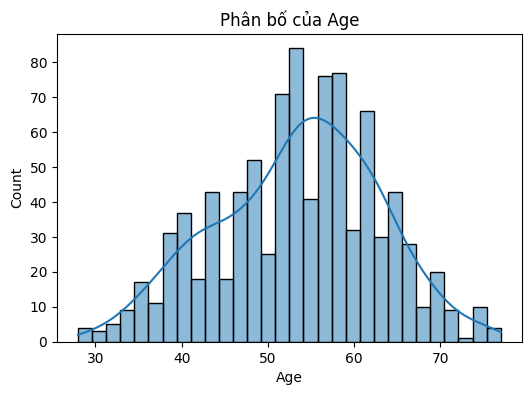

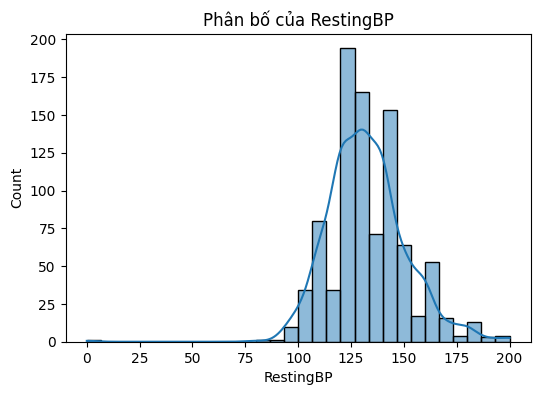

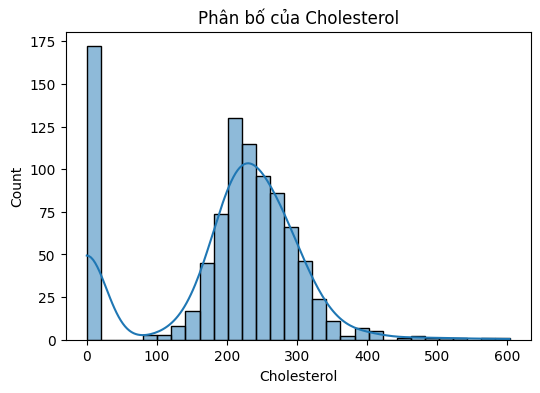

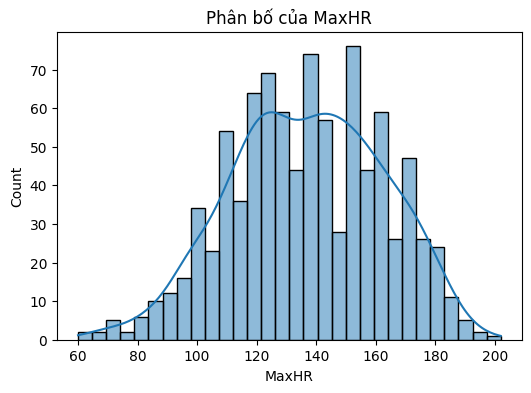

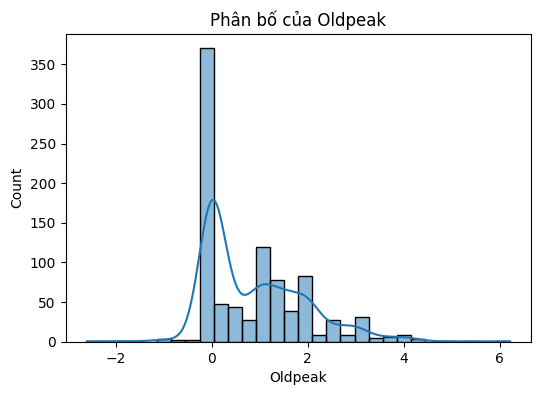

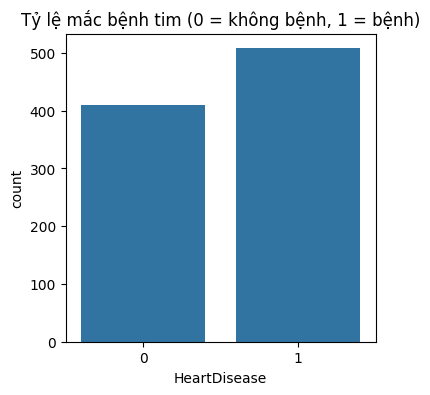

Tỷ lệ mắc bệnh tim:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


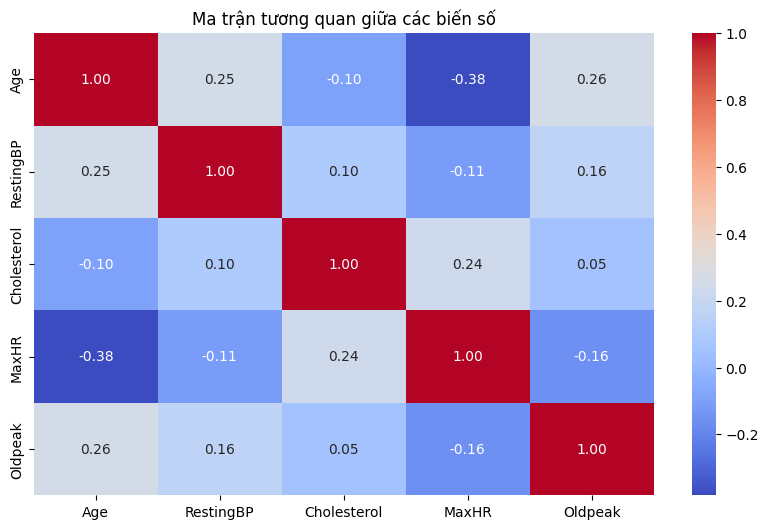

Cholesterol: giới hạn dưới = 32.62, giới hạn trên = 407.62
Số lượng outlier: 183
RestingBP: giới hạn dưới = 90.00, giới hạn trên = 170.00
Số lượng outlier: 28
Oldpeak: giới hạn dưới = -2.25, giới hạn trên = 3.75
Số lượng outlier: 16
Hoàn tất xử lý outlier.


In [106]:


import matplotlib.pyplot as plt
import seaborn as sns

df = df1.copy()  

print("Tổng quan dữ liệu Dataset 1:")
display(df.head())
print(df.describe(include='all'))



num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Phân bố của {col}")
    plt.show()


plt.figure(figsize=(4,4))
sns.countplot(x=df["HeartDisease"])
plt.title("Tỷ lệ mắc bệnh tim (0 = không bệnh, 1 = bệnh)")
plt.show()

print("Tỷ lệ mắc bệnh tim:")
print(df["HeartDisease"].value_counts(normalize=True))


plt.figure(figsize=(10, 6))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()



def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"{column}: giới hạn dưới = {lower:.2f}, giới hạn trên = {upper:.2f}")
    print(f"Số lượng outlier: {(df[column] < lower).sum() + (df[column] > upper).sum()}")
    
    
    df[column] = df[column].clip(lower, upper)
    return df

for col in ["Cholesterol", "RestingBP", "Oldpeak"]:
    df = remove_outliers_iqr(df, col)

print("Hoàn tất xử lý outlier.")

df1 = df.copy()


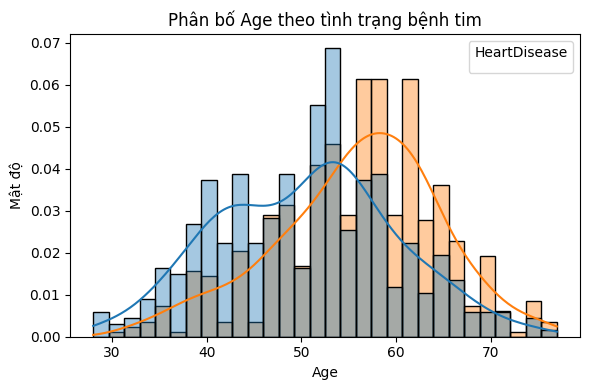

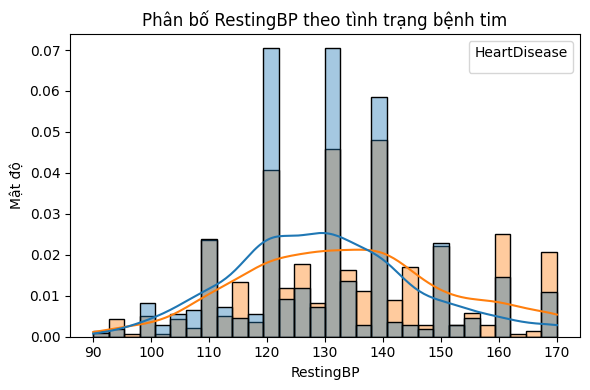

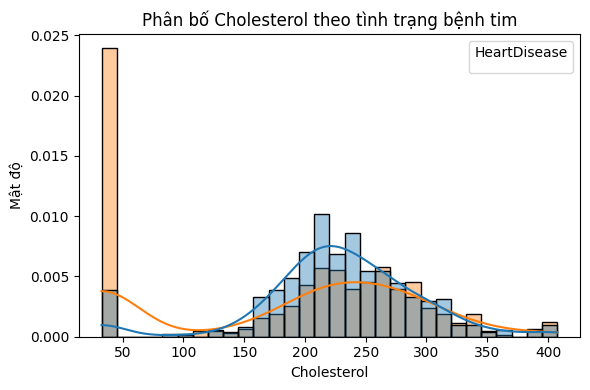

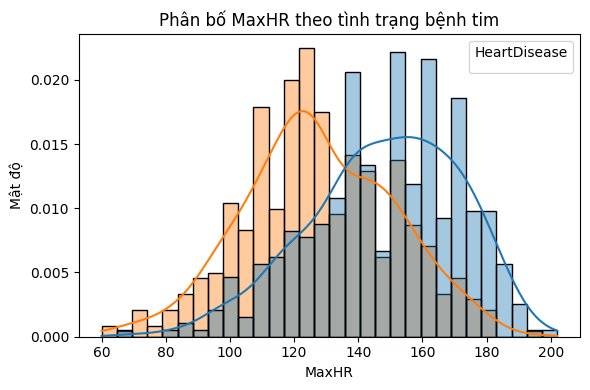

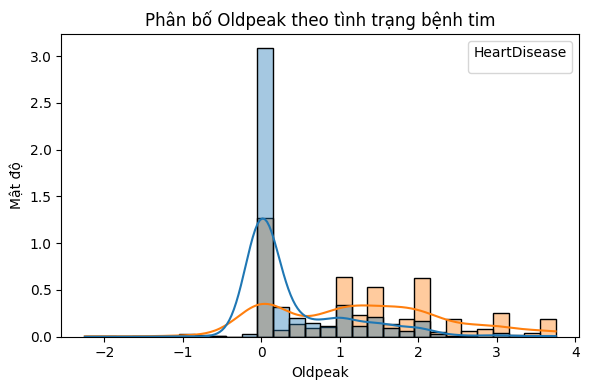

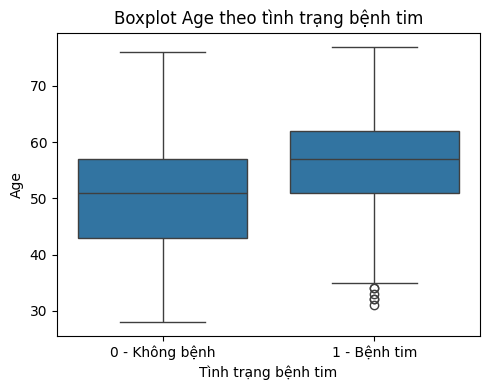

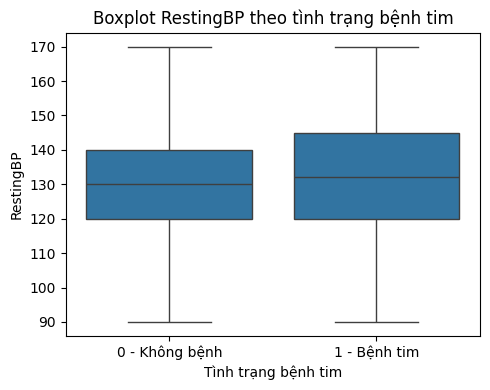

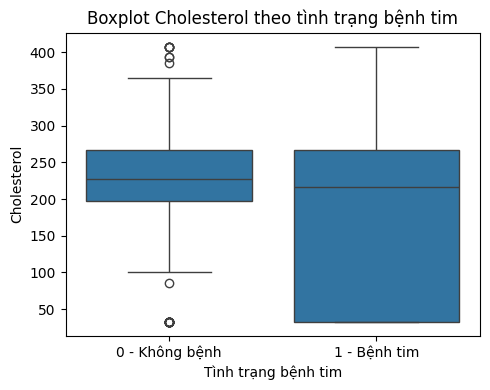

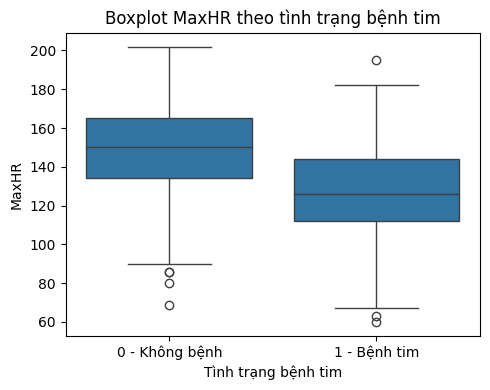

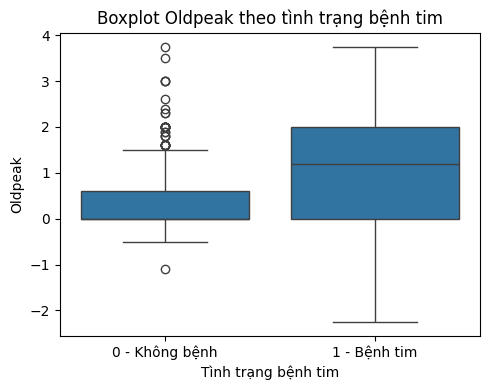

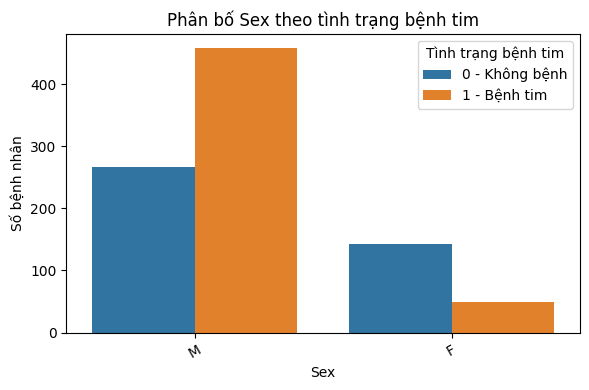

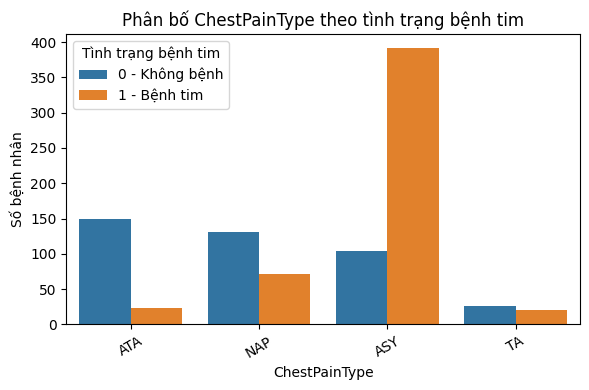

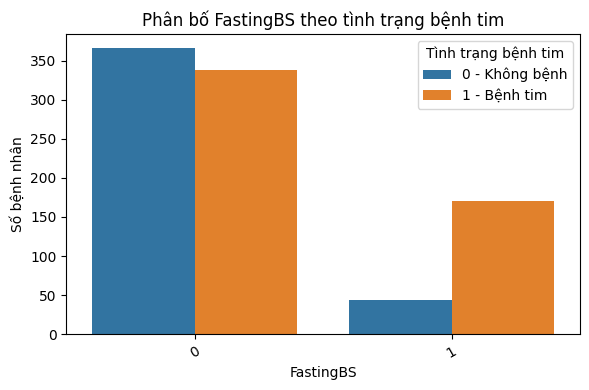

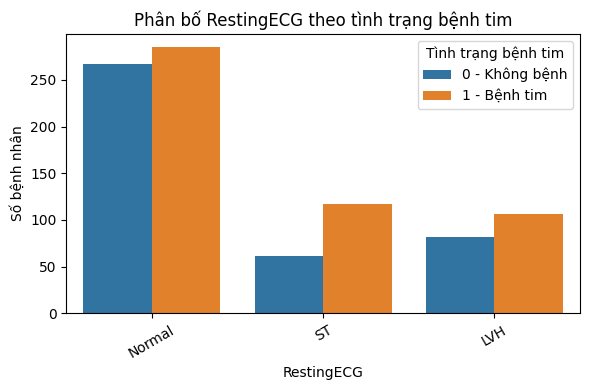

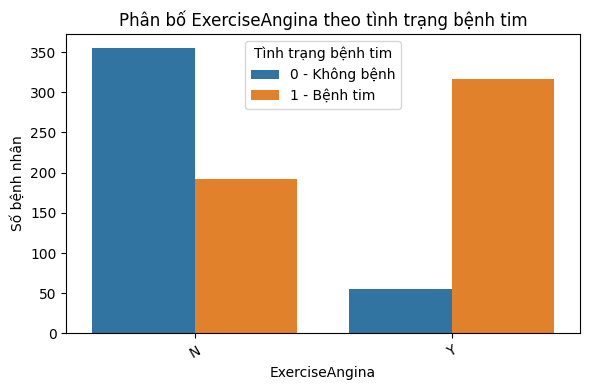

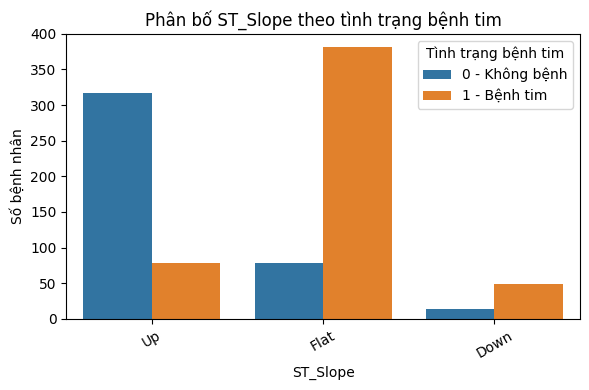


Tỉ lệ HeartDisease theo Sex:
     P(không bệnh)  P(bệnh tim)
Sex                            
F             0.74         0.26
M             0.37         0.63

Tỉ lệ HeartDisease theo ChestPainType:
               P(không bệnh)  P(bệnh tim)
ChestPainType                            
ASY                     0.21         0.79
ATA                     0.86         0.14
NAP                     0.65         0.35
TA                      0.57         0.43

Tỉ lệ HeartDisease theo FastingBS:
           P(không bệnh)  P(bệnh tim)
FastingBS                            
0                   0.52         0.48
1                   0.21         0.79

Tỉ lệ HeartDisease theo RestingECG:
            P(không bệnh)  P(bệnh tim)
RestingECG                            
LVH                  0.44         0.56
Normal               0.48         0.52
ST                   0.34         0.66

Tỉ lệ HeartDisease theo ExerciseAngina:
                P(không bệnh)  P(bệnh tim)
ExerciseAngina                            
N  

In [107]:
# Tạo cột nhãn dạng chữ cho trực quan
df1['HeartDisease_label'] = df1['HeartDisease'].map({
    0: '0 - Không bệnh',
    1: '1 - Bệnh tim'
})

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df1,
        x=col,
        hue='HeartDisease_label',     # phân màu theo nhãn
        kde=True,
        bins=30,
        stat='density',
        common_norm=False,            # để mỗi nhóm tự chuẩn hóa, so sánh hình dạng phân bố
        alpha=0.4
    )
    plt.title(f'Phân bố {col} theo tình trạng bệnh tim')
    plt.xlabel(col)
    plt.ylabel('Mật độ')
    plt.legend(title='HeartDisease')
    plt.tight_layout()
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=df1,
        x='HeartDisease_label',
        y=col
    )
    plt.title(f'Boxplot {col} theo tình trạng bệnh tim')
    plt.xlabel('Tình trạng bệnh tim')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


categorical_cols = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df1,
        x=col,
        hue='HeartDisease_label'
    )
    plt.title(f'Phân bố {col} theo tình trạng bệnh tim')
    plt.xlabel(col)
    plt.ylabel('Số bệnh nhân')
    plt.xticks(rotation=30)
    plt.legend(title='Tình trạng bệnh tim')
    plt.tight_layout()
    plt.show()


for col in categorical_cols:
    print(f'\nTỉ lệ HeartDisease theo {col}:')
    ct = pd.crosstab(df1[col], df1['HeartDisease'], normalize='index').round(2)
    ct.columns = ['P(không bệnh)', 'P(bệnh tim)']
    print(ct)

## Step 3: Tiền xử lý & chia train/val/test cho Dataset 1 (Screening)

In [108]:
# ============================================================
# Step 3: Tiền xử lý & chia train/val/test cho Dataset 1 (Screening)
# ============================================================

if 'HeartDisease' in df1.columns:
    label1 = 'HeartDisease'
elif 'heart_disease' in df1.columns:
    label1 = 'heart_disease'
else:
    label1 = df1.columns[-1]

drop_cols = [label1] + [c for c in df1.columns if c.endswith('_label')]
X1 = df1.drop(columns=drop_cols, errors='ignore').copy()
y1 = df1[label1].astype(int)

numeric_cols1 = X1.select_dtypes(include=[np.number]).columns.tolist()
cat_cols1 = [c for c in X1.columns if c not in numeric_cols1]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor1 = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols1),
    ('cat', categorical_transformer, cat_cols1)
])

X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=42
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.50, stratify=y1_temp, random_state=42
)


## Step 4: Huấn luyện & đánh giá mô hình Screening 

In [109]:
# ============================================================
# Step 4: Huấn luyện & đánh giá mô hình Screening 
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, auc,   
    balanced_accuracy_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
import joblib

# ------------------------------------------------------------
# Hàm đánh giá mô hình với threshold mặc định 0.5
# ------------------------------------------------------------
def evaluate_model(pipe, X, y, name="model"):
    """Đánh giá mô hình phân loại nhị phân với nhiều thước đo.

    Dùng .predict_proba() để lấy xác suất, .predict() với threshold mặc định 0.5
    để tính các chỉ số: Accuracy, Precision, Recall, F1, AUC-ROC, AUC-PR,
    Specificity, Balanced Accuracy.
    """
    y_proba = pipe.predict_proba(X)[:, 1]
    y_pred = pipe.predict(X)   # threshold = 0.5

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)  # Sensitivity
    f1 = f1_score(y, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y, y_proba)

    precisions, recalls, _ = precision_recall_curve(y, y_proba)
    auc_pr = auc(recalls, precisions)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_acc = balanced_accuracy_score(y, y_pred)

    metrics = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "specificity": specificity,
        "balanced_accuracy": balanced_acc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    print(f"=== {name} ===")
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision           : {prec:.4f}")
    print(f"Recall (Sensitivity): {rec:.4f}")
    print(f"Specificity         : {specificity:.4f}")
    print(f"Balanced Accuracy   : {balanced_acc:.4f}")
    print(f"F1-score            : {f1:.4f}")
    print(f"AUC-ROC             : {auc_roc:.4f}")
    print(f"AUC(PR)             : {auc_pr:.4f}")
    print("-" * 60)

    return metrics

# ------------------------------------------------------------
# 1) Chuẩn bị: gộp train + val để dùng sau khi đã chọn mô hình
# ------------------------------------------------------------
X1_train_full = pd.concat([X1_train, X1_val], axis=0)
y1_train_full = pd.concat([y1_train, y1_val], axis=0)

# ------------------------------------------------------------
# 2) Đánh giá Logistic Regression bằng cross-validation trên tập train
# ------------------------------------------------------------
pipe_lr1_base = Pipeline([
    ("pre", preprocessor1),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

cv_lr1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr1 = cross_val_score(
    pipe_lr1_base,
    X1_train,
    y1_train,
    cv=cv_lr1,
    scoring="roc_auc",
    n_jobs=-1
)
mean_auc_lr1 = cv_scores_lr1.mean()
std_auc_lr1 = cv_scores_lr1.std()
print(">>> Logistic Regression – DS1 – CV AUC (mean ± std): "
      f"{mean_auc_lr1:.4f} ± {std_auc_lr1:.4f}")

# ------------------------------------------------------------
# 3) Tune RandomForest bằng GridSearchCV trên tập train
# ------------------------------------------------------------
rf_base_ds1 = Pipeline([
    ("pre", preprocessor1),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_rf1 = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.8],
}

cv_rf1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf1 = GridSearchCV(
    estimator=rf_base_ds1,
    param_grid=param_grid_rf1,
    cv=cv_rf1,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(">>> Bắt đầu GridSearchCV cho RandomForest – DS1 (chỉ dùng TRAIN)...")
grid_rf1.fit(X1_train, y1_train)
print(">>> Best params RF – DS1:", grid_rf1.best_params_)
print(">>> Best CV AUC – RF – DS1:", grid_rf1.best_score_)

best_rf1_cv = grid_rf1.best_estimator_
best_auc_rf1 = grid_rf1.best_score_

# ------------------------------------------------------------
# 4) So sánh AUC-CV giữa Logistic Regression và RandomForest
# ------------------------------------------------------------
if best_auc_rf1 > mean_auc_lr1:
    print("\n>>> Chọn RandomForest cho DS1 (AUC-CV cao hơn LR).")
    best_model_label_ds1 = "RandomForest"
    best_pipe_ds1 = best_rf1_cv
else:
    print("\n>>> Chọn Logistic Regression cho DS1 (AUC-CV cao hơn hoặc bằng RF).")
    best_model_label_ds1 = "LogisticRegression"
    best_pipe_ds1 = pipe_lr1_base

# ------------------------------------------------------------
# 5) Fit lại mô hình đã chọn trên TRAIN + VAL, sau đó đánh giá trên TEST
# ------------------------------------------------------------
best_pipe_ds1.fit(X1_train, y1_train)
print("\n>>> Đã fit mô hình đã chọn cho DS1 trên TRAIN (để tune threshold).")
# ------------------------------------------------------------



>>> Logistic Regression – DS1 – CV AUC (mean ± std): 0.9193 ± 0.0282
>>> Bắt đầu GridSearchCV cho RandomForest – DS1 (chỉ dùng TRAIN)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
>>> Best params RF – DS1: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
>>> Best CV AUC – RF – DS1: 0.9234886633777256

>>> Chọn RandomForest cho DS1 (AUC-CV cao hơn LR).

>>> Đã fit mô hình đã chọn cho DS1 trên TRAIN (để tune threshold).


## Step 5: Chọn threshold + đánh giá test

In [110]:
# ============================================================
# Step 5: Chọn threshold tối ưu & đánh giá mô hình trên TEST
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
import numpy as np

# ------------------------------------------------------------
# Hàm đánh giá tại một threshold cụ thể 
# ------------------------------------------------------------
def evaluate_at_threshold(y_true, y_proba, threshold=0.5, name="model@th"):
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_acc = (rec + specificity) / 2 if (rec + specificity) > 0 else 0.0
    auc_roc = roc_auc_score(y_true, y_proba)

    print(f"=== {name} (threshold={threshold:.3f}) ===")
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision           : {prec:.4f}")
    print(f"Recall (Sensitivity): {rec:.4f}")
    print(f"Specificity         : {specificity:.4f}")
    print(f"Balanced Accuracy   : {balanced_acc:.4f}")
    print(f"F1-score            : {f1:.4f}")
    print(f"AUC-ROC             : {auc_roc:.4f}")
    print("-" * 60)

    return {
        "threshold": threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "balanced_accuracy": balanced_acc,
        "f1": f1,
        "auc_roc": auc_roc,
    }

# ------------------------------------------------------------
# Hàm tìm threshold tối ưu trên VALIDATION
# ------------------------------------------------------------
def tune_threshold_on_validation(
    y_true,
    y_proba,
    metric="recall",
    min_recall=None,
    min_precision=None,
):
    thresholds = np.linspace(0.05, 0.95, 91)

    rows = []

    best_th = 0.5
    best_score = -1

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        # Constraints
        if metric == "recall" and min_precision is not None:
            if prec < min_precision:
                continue

        if metric in ("precision", "f1") and min_recall is not None:
            if rec < min_recall:
                continue

        # Score selection
        if metric == "recall":
            score = rec
        elif metric == "precision":
            score = prec
        else:
            score = f1

        rows.append({
            "threshold": th,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "score_used": score,
        })

        if score > best_score:
            best_score = score
            best_th = th

    table = pd.DataFrame(rows)

    return best_th, table


# ---------- DS1: tune threshold trên VAL, rồi evaluate trên TEST ----------

# 1) Tìm threshold tốt nhất trên validation (ƯU TIÊN RECALL)
y1_val_proba = best_pipe_ds1.predict_proba(X1_val)[:, 1]

best_th_ds1, table_th_ds1 = tune_threshold_on_validation(
    y1_val,
    y1_val_proba,
    metric="recall",
    min_precision=0.5
)

print("Best threshold DS1:", best_th_ds1)
display(table_th_ds1.head())

print("\n>>> Threshold tuning trên VALIDATION (DS1)")
print(f"- Optimized metric        : {th_info_ds1['optimized_metric']}")
print(f"- Min recall constraint   : {th_info_ds1['min_recall_constraint']}")
print(f"- Min precision constraint: {th_info_ds1['min_precision_constraint']}")
print(f"- Best threshold          : {best_th_ds1:.3f}")
print(f"- Recall tại best_th      : {th_info_ds1['recall_at_best_th']:.4f}")
print(f"- Precision tại best_th   : {th_info_ds1['precision_at_best_th']:.4f}")
print(f"- F1 tại best_th          : {th_info_ds1['f1_at_best_th']:.4f}")
print("-" * 60)

# 2) Đánh giá trên TEST với threshold mặc định 0.5 (baseline)
y1_test_proba = best_pipe_ds1.predict_proba(X1_test)[:, 1]
metrics_05_ds1 = evaluate_at_threshold(
    y1_test, y1_test_proba,
    threshold=0.5,
    name=f"{best_model_label_ds1}_DS1 @ threshold=0.5 (baseline test)"
)

# 3) Đánh giá trên TEST với threshold tối ưu (final - ƯU TIÊN RECALL)
metrics_th_ds1 = evaluate_at_threshold(
    y1_test, y1_test_proba,
    threshold=best_th_ds1,
    name=f"{best_model_label_ds1}_DS1 @ tuned_threshold (final test)"
)


from sklearn.base import clone

final_pipe_ds1 = clone(best_pipe_ds1)
final_pipe_ds1.fit(X1_train_full, y1_train_full)

# Lưu model dùng trong thực tế
MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path_ds1 = MODEL_DIR / ("best_ds1_" + best_model_label_ds1 + ".pkl")
joblib.dump(final_pipe_ds1, best_model_path_ds1)
print(f"Đã lưu mô hình tốt nhất DS1 (train+val) vào: {best_model_path_ds1}")

Best threshold DS1: 0.05


,threshold,precision,recall,f1,score_used
0,0.05,0.647059,1.000000,0.785714,1.000000
1,0.06,0.647059,1.000000,0.785714,1.000000
2,0.07,0.655172,0.987013,0.787565,0.987013
3,0.08,0.660870,0.987013,0.791667,0.987013
4,0.09,0.672566,0.987013,0.800000,0.987013



>>> Threshold tuning trên VALIDATION (DS1)
- Optimized metric        : recall
- Min recall constraint   : None
- Min precision constraint: 0.5
- Best threshold          : 0.050
- Recall tại best_th      : 1.0000
- Precision tại best_th   : 0.6471
- F1 tại best_th          : 0.7857
------------------------------------------------------------
=== RandomForest_DS1 @ threshold=0.5 (baseline test) (threshold=0.500) ===
Accuracy            : 0.8986
Precision           : 0.9306
Recall (Sensitivity): 0.8816
Specificity         : 0.9194
Balanced Accuracy   : 0.9005
F1-score            : 0.9054
AUC-ROC             : 0.9516
------------------------------------------------------------
=== RandomForest_DS1 @ tuned_threshold (final test) (threshold=0.050) ===
Accuracy            : 0.7174
Precision           : 0.6637
Recall (Sensitivity): 0.9868
Specificity         : 0.3871
Balanced Accuracy   : 0.6870
F1-score            : 0.7937
AUC-ROC             : 0.9516
----------------------------------------

## Step 6: Calibration

Brier score – DS1 (càng thấp càng tốt): 0.0942


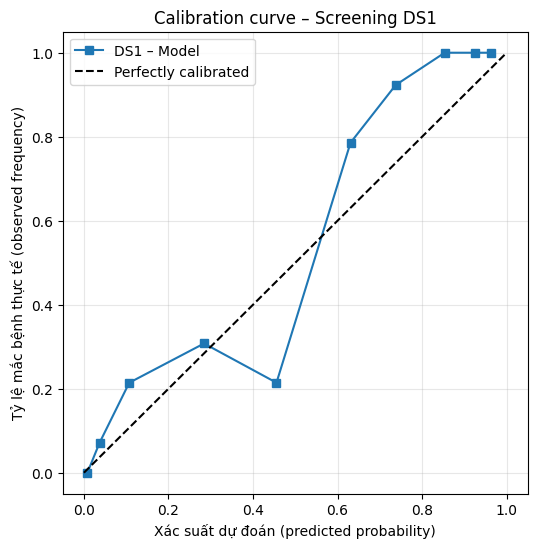

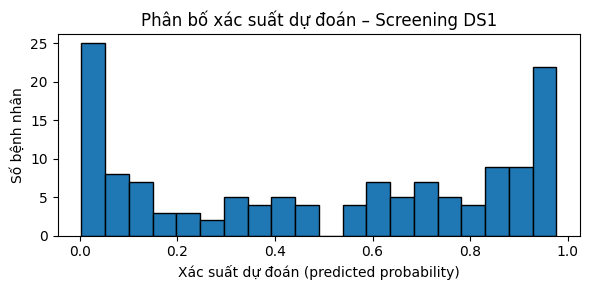

In [111]:
# ============================================================
# Step 6: Calibration cho mô hình Screening 
# ============================================================

# 1) Lấy xác suất dự đoán từ mô hình tốt nhất DS1
y1_proba = y1_test_proba   # xác suất bị bệnh tim (label=1)

# 2) Tính Brier Score cho DS1
brier_ds1 = brier_score_loss(y1_test, y1_proba)
print(f"Brier score – DS1 (càng thấp càng tốt): {brier_ds1:.4f}")

# 3) Tính dữ liệu cho calibration curve
prob_true1, prob_pred1 = calibration_curve(
    y1_test,
    y1_proba,
    n_bins=10,
    strategy="quantile"
)

# 4) Vẽ Calibration Curve cho DS1
plt.figure(figsize=(6, 6))
plt.plot(prob_pred1, prob_true1, "s-", label="DS1 – Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Xác suất dự đoán (predicted probability)")
plt.ylabel("Tỷ lệ mắc bệnh thực tế (observed frequency)")
plt.title("Calibration curve – Screening DS1")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()


# Histogram của y1_proba
plt.figure(figsize=(6, 3))
plt.hist(y1_proba, bins=20, edgecolor="black")
plt.xlabel("Xác suất dự đoán (predicted probability)")
plt.ylabel("Số bệnh nhân")
plt.title("Phân bố xác suất dự đoán – Screening DS1")
plt.tight_layout()
plt.show()



## Step 7: Vẽ ROC, Confusion Matrix, Precision–Recall cho Dataset 1

In [112]:
# ============================================================
# Step 7: Vẽ ROC, Confusion Matrix, Precision–Recall cho DS1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    confusion_matrix,
    precision_recall_curve,
    auc,
    average_precision_score,
)

# ------------------------------------------------------------
# Hàm vẽ ROC curve
# ------------------------------------------------------------
def plot_roc(y_true, y_proba, title="ROC Curve"):
    """
    Vẽ ROC curve và tính AUC.
    y_true  : nhãn thật (0/1)
    y_proba : xác suất dự đoán lớp 1
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Hàm vẽ Confusion Matrix + in các chỉ số Sens/Spec/Balanced Acc
# ------------------------------------------------------------
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    """
    Vẽ confusion matrix và in thêm:
    - Sensitivity (Recall)
    - Specificity
    - Balanced Accuracy
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Dự đoán: Không bệnh", "Dự đoán: Bệnh"],
        yticklabels=["Thực tế: Không bệnh", "Thực tế: Bệnh"],
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    balanced_acc = (specificity + sensitivity) / 2

    print(f"Sensitivity (Recall, True Positive Rate): {sensitivity:.4f}")
    print(f"Specificity (True Negative Rate)        : {specificity:.4f}")
    print(f"Balanced Accuracy                       : {balanced_acc:.4f}")

# ------------------------------------------------------------
# Hàm vẽ Precision–Recall curve
# ------------------------------------------------------------
def plot_precision_recall(y_true, y_proba, title="Precision–Recall Curve"):
    """
    Vẽ Precision–Recall curve và tính:
    - PR AUC (auc(recall, precision))
    - Average Precision (AP)
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recalls, precisions)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}, AP = {ap:.3f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Áp dụng cho DS1 với mô hình tốt nhất và threshold đã tune
# ------------------------------------------------------------

# 1) Xác suất dự đoán trên TEST từ mô hình tốt nhất
#    (không phụ thuộc threshold)
y1_test_proba_best = best_pipe_ds1.predict_proba(X1_test)[:, 1]


model_label_vn = best_model_label_ds1





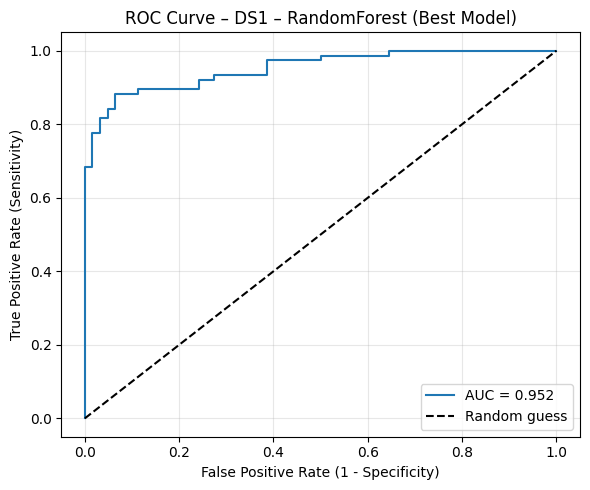

In [113]:
# 2) ROC curve – đánh giá khả năng phân biệt của mô hình
plot_roc(
    y1_test,
    y1_test_proba_best,
    title=f"ROC Curve – DS1 – {model_label_vn} (Best Model)"
)

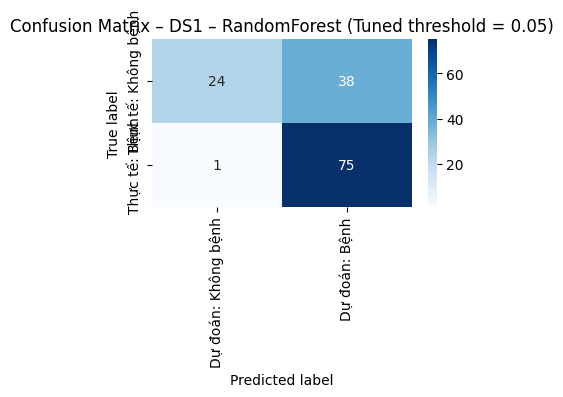

Sensitivity (Recall, True Positive Rate): 0.9868
Specificity (True Negative Rate)        : 0.3871
Balanced Accuracy                       : 0.6870


In [114]:
# 3) Confusion Matrix tại threshold đã tune (ưu tiên Recall)
#    best_th_ds1 được tìm ở Step 5 bằng tune_threshold_on_validation
y1_test_pred_tuned = (y1_test_proba_best >= best_th_ds1).astype(int)

plot_confusion(
    y1_test,
    y1_test_pred_tuned,
    title=f"Confusion Matrix – DS1 – {model_label_vn} (Tuned threshold = {best_th_ds1:.2f})"
)

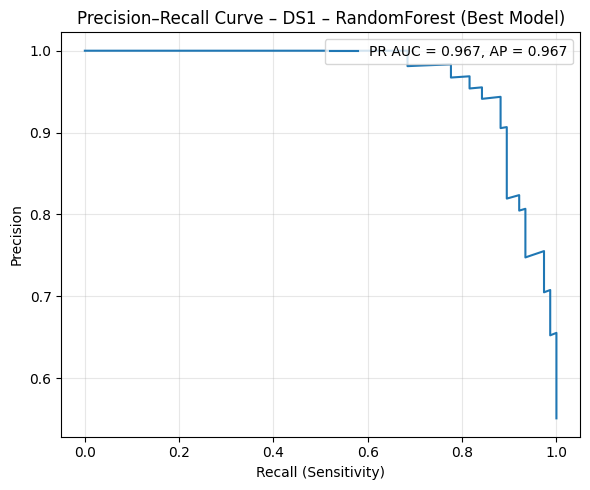

In [115]:
# 4) Precision–Recall curve – đánh giá trade-off Recall/Precision
plot_precision_recall(
    y1_test,
    y1_test_proba_best,
    title=f"Precision–Recall Curve – DS1 – {model_label_vn} (Best Model)"
)

## Step 8: Giải thích mô hình Screening: Feature Importance & SHAP (Dataset 1)

Tổng số feature DS1: 20

Top 10 features quan trọng nhất (Permutation Importance – theo AUC):


Cholesterol          0.019058
ST_Slope_Up          0.018739
ChestPainType_ASY    0.015068
ST_Slope_Flat        0.012596
Oldpeak              0.008712
ExerciseAngina_Y     0.008351
RestingBP            0.005369
Sex_M                0.004626
Sex_F                0.004372
ExerciseAngina_N     0.004255
dtype: float64

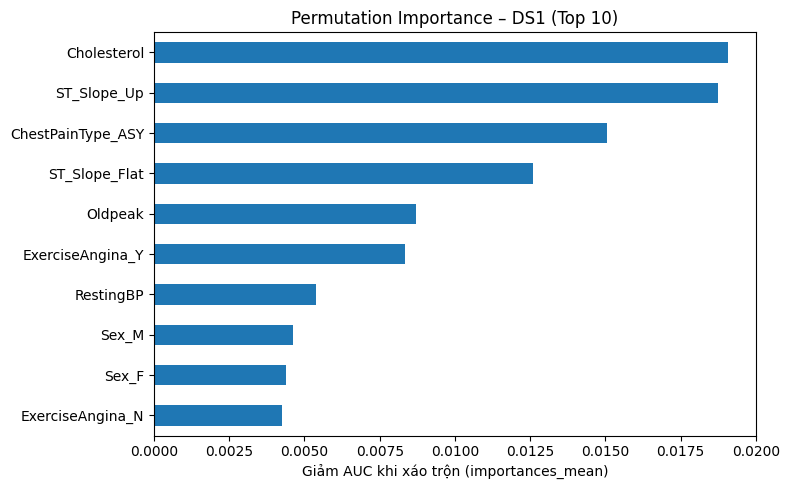

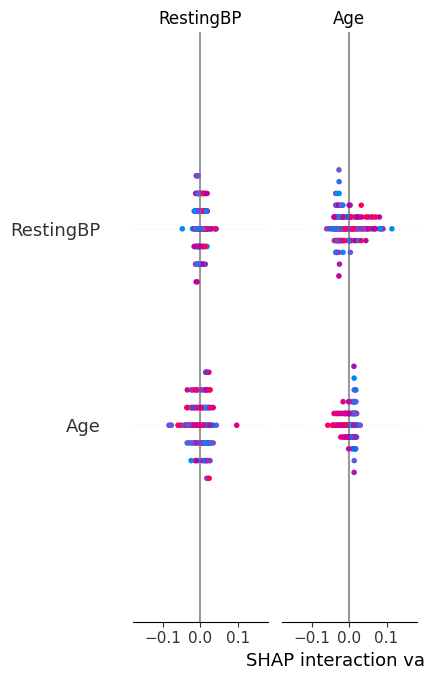

In [116]:
# ============================================================
# Step 8: Giải thích mô hình Screening DS1 – Feature Importance & SHAP
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from scipy import sparse

pre1 = best_pipe_ds1.named_steps["pre"]
clf1 = best_pipe_ds1.named_steps["clf"]

# ---- 1) Lấy tên cột sau preprocess, đúng thứ tự ----
feature_names1 = []

# numeric trước
feature_names1.extend(numeric_cols1)

# categorical (đúng thứ tự one-hot)
try:
    ohe1 = pre1.named_transformers_["cat"].named_steps["onehot"]
    ohe_feature_names1 = ohe1.get_feature_names_out(cat_cols1)
    feature_names1.extend(list(ohe_feature_names1))
except Exception as e:
    print("Không lấy được tên cột từ OneHotEncoder, dùng tên cột gốc cho phần categorical.")
    feature_names1.extend(cat_cols1)

print("Tổng số feature DS1:", len(feature_names1))

# ---- 2) Biến đổi X_test qua preprocessor ----
X1_test_trans = pre1.transform(X1_test)

# Đảm bảo số chiều khớp với feature_names
assert X1_test_trans.shape[1] == len(feature_names1), \
    f"Số cột sau transform ({X1_test_trans.shape[1]}) khác số feature_names ({len(feature_names1)})"

# Chuẩn bị bản dense cho SHAP (phòng trường hợp ColumnTransformer trả về sparse)
if sparse.issparse(X1_test_trans):
    X1_test_dense = X1_test_trans.toarray()
else:
    X1_test_dense = X1_test_trans

# (Optional) Lấy mẫu cho SHAP để chạy nhanh hơn
max_shap_samples = 300
if X1_test_dense.shape[0] > max_shap_samples:
    rng = np.random.RandomState(42)
    idx = rng.choice(X1_test_dense.shape[0], max_shap_samples, replace=False)
    X1_shap = X1_test_dense[idx]
else:
    X1_shap = X1_test_dense

# ---- 3) PERMUTATION IMPORTANCE (theo AUC) ----
try:
    r1 = permutation_importance(
        clf1,
        X1_test_trans,
        y1_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1,
        scoring="roc_auc",  # ưu tiên AUC cho bài toán phân loại
    )
    fi1 = pd.Series(r1.importances_mean, index=feature_names1).sort_values(ascending=False)

    print("\nTop 10 features quan trọng nhất (Permutation Importance – theo AUC):")
    display(fi1.head(10))

    plt.figure(figsize=(8, 5))
    fi1.head(10).sort_values().plot(kind="barh")
    plt.title("Permutation Importance – DS1 (Top 10)")
    plt.xlabel("Giảm AUC khi xáo trộn (importances_mean)")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Permutation importance failed DS1:", e)

# ---- 4) SHAP ----
try:
    if hasattr(clf1, "feature_importances_"):   # RandomForest, tree-based
        explainer1 = shap.TreeExplainer(clf1)
        shap_vals1 = explainer1.shap_values(X1_shap)

        # shap_values cho classifier: list theo class
        if isinstance(shap_vals1, list):
            shap_vals1 = shap_vals1[1]  # lớp positive (HeartDisease = 1)

        shap.summary_plot(
            shap_vals1,
            X1_shap,
            feature_names=feature_names1,
            plot_type="dot",
            show=True
        )

    else:  # Logistic Regression / Linear model
        explainer1 = shap.LinearExplainer(clf1, X1_test_dense)
        shap_vals1 = explainer1.shap_values(X1_shap)

        shap.summary_plot(
            shap_vals1,
            X1_shap,
            feature_names=feature_names1,
            plot_type="dot",
            show=True
        )

except Exception as e:
    print("SHAP DS1 failed:", e)


## Step 9: Đánh giá Fairness theo giới tính

In [117]:
# ============================================================
# Step 9: ĐÁNH GIÁ FAIRNESS cho mô hình Screening DS1 theo giới tính
# ============================================================

from sklearn.metrics import confusion_matrix, accuracy_score

# 1) Xác định cột giới tính
sex_candidates = [c for c in df1.columns if 'sex' in c.lower()]
if not sex_candidates:
    print("Không tìm thấy cột giới tính.")
else:
    sex_col = sex_candidates[0]

    # 2) Chuẩn bị prediction trên TEST với threshold đã tune
    y1_test_proba_best = best_pipe_ds1.predict_proba(X1_test)[:, 1]
    y1_test_pred_tuned = (y1_test_proba_best >= best_th_ds1).astype(int)

    # 3) Tạo dataframe fairness
    df1_eval = pd.DataFrame(index=X1_test.index)
    df1_eval['Sex'] = df1.loc[X1_test.index, sex_col]
    df1_eval['y_true'] = y1_test.values
    df1_eval['y_pred'] = y1_test_pred_tuned

    # 4) Tính fairness theo nhóm giới tính
    results = []
    for group, data in df1_eval.groupby('Sex'):
        cm = confusion_matrix(data['y_true'], data['y_pred'], labels=[0, 1])

        # đảm bảo ravel được 4 phần tử
        if cm.shape == (1, 1):
            if data['y_true'].unique()[0] == 0:
                tn, fp, fn, tp = cm[0, 0], 0, 0, 0
            else:
                tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
        else:
            tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        balanced_acc = (sensitivity + specificity) / 2

        results.append({
            "Group (Sex)": group,
            "N": len(data),
            "Accuracy": accuracy_score(data['y_true'], data['y_pred']),
            "Positive Rate (Pred=1)": data['y_pred'].mean(),
            "Recall (Sensitivity)": sensitivity,
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "Balanced Accuracy": balanced_acc
        })

    fairness_df = pd.DataFrame(results)
    print("\n=== Fairness theo giới tính (DS1, tuned threshold) ===")
    display(fairness_df)


# ============================================================
# So sánh FAIRNESS theo giới tính: threshold 0.5 vs threshold đã tune
# ============================================================

from sklearn.metrics import confusion_matrix, accuracy_score

# 1) Xác định cột giới tính
sex_candidates = [c for c in df1.columns if "sex" in c.lower()]
if not sex_candidates:
    print("Không tìm thấy cột giới tính.")
else:
    sex_col = sex_candidates[0]

    # 2) Tính xác suất và 2 bộ dự đoán (0.5 và tuned)
    y1_test_proba_best = best_pipe_ds1.predict_proba(X1_test)[:, 1]
    y1_test_pred_05 = (y1_test_proba_best >= 0.5).astype(int)
    y1_test_pred_tuned = (y1_test_proba_best >= best_th_ds1).astype(int)

    # 3) Tạo dataframe chung cho fairness
    df1_eval = pd.DataFrame(index=X1_test.index)
    df1_eval["Sex"] = df1.loc[X1_test.index, sex_col]
    df1_eval["y_true"] = y1_test.values
    df1_eval["y_pred_05"] = y1_test_pred_05
    df1_eval["y_pred_tuned"] = y1_test_pred_tuned

    # 4) Hàm tính metric fairness cho 1 cột dự đoán
    def compute_fairness_for_pred_col(df_eval, pred_col, th_label):
        results = []
        for group, data in df_eval.groupby("Sex"):
            cm = confusion_matrix(data["y_true"], data[pred_col], labels=[0, 1])

            # đảm bảo luôn có đủ 4 phần tử
            if cm.shape == (1, 1):
                if data["y_true"].unique()[0] == 0:
                    tn, fp, fn, tp = cm[0, 0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
            else:
                tn, fp, fn, tp = cm.ravel()

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
            balanced_acc = (sensitivity + specificity) / 2

            results.append({
                "Threshold": th_label,
                "Group (Sex)": group,
                "N": len(data),
                "Accuracy": accuracy_score(data["y_true"], data[pred_col]),
                "Positive Rate (Pred=1)": data[pred_col].mean(),
                "Recall (Sensitivity)": sensitivity,
                "Specificity": specificity,
                "FPR": fpr,
                "FNR": fnr,
                "Balanced Accuracy": balanced_acc,
            })

        return pd.DataFrame(results)

    # 5) Tính fairness cho cả hai threshold
    fairness_05 = compute_fairness_for_pred_col(df1_eval, "y_pred_05",  "0.50 (baseline)")
    fairness_tuned = compute_fairness_for_pred_col(df1_eval, "y_pred_tuned", f"{best_th_ds1:.2f} (tuned)")

    # 6) Gộp lại để so sánh
    fairness_compare = pd.concat([fairness_05, fairness_tuned], ignore_index=True)
    print("\n=== So sánh FAIRNESS theo giới tính – DS1 ===")
    display(fairness_compare)




=== Fairness theo giới tính (DS1, tuned threshold) ===


,Group (Sex),N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
0,F,33,0.333333,0.818182,1.000000,0.214286,0.785714,0.000000,0.607143
1,M,105,0.838095,0.819048,0.985915,0.529412,0.470588,0.014085,0.757664



=== So sánh FAIRNESS theo giới tính – DS1 ===


,Threshold,Group (Sex),N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
0,0.50 (baseline),F,33,0.909091,0.181818,0.800000,0.928571,0.071429,0.200000,0.864286
1,0.50 (baseline),M,105,0.895238,0.628571,0.887324,0.911765,0.088235,0.112676,0.899544
2,0.05 (tuned),F,33,0.333333,0.818182,1.000000,0.214286,0.785714,0.000000,0.607143
3,0.05 (tuned),M,105,0.838095,0.819048,0.985915,0.529412,0.470588,0.014085,0.757664


# Dataset 2

## Step 1: EDA và xử lý outliers

Tổng quan dữ liệu Dataset 2 (Heart Failure):


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

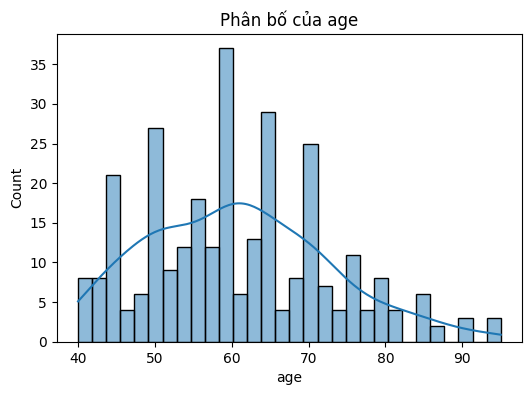

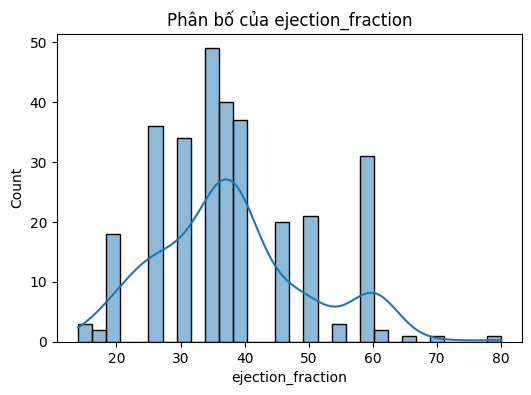

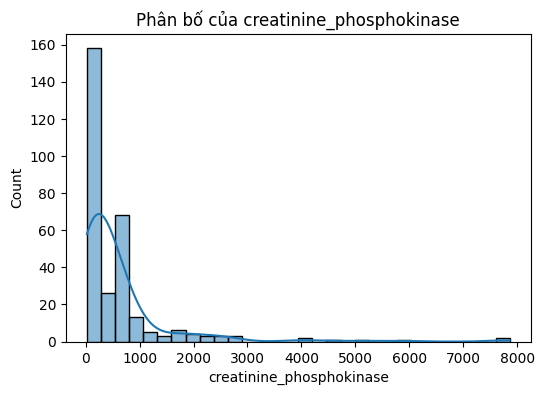

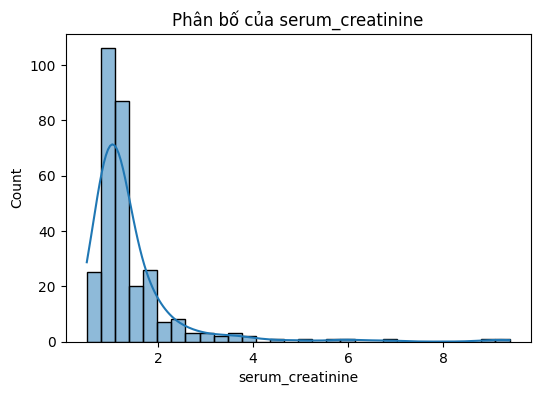

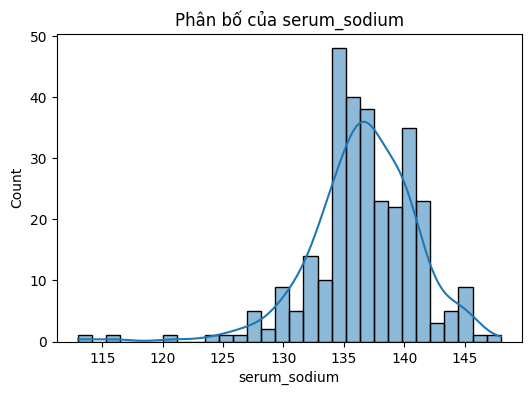

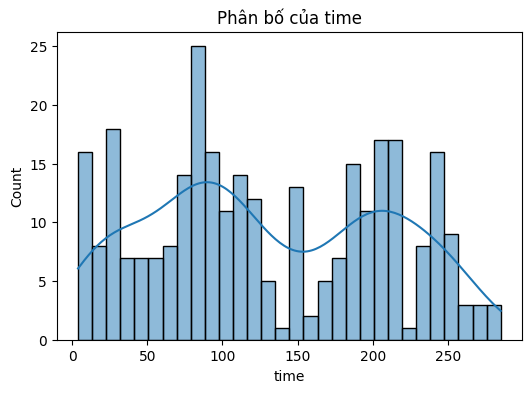

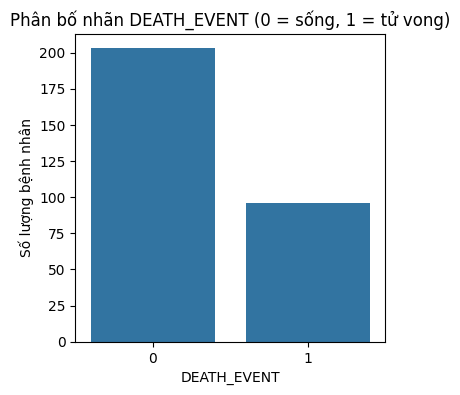

Số lượng từng lớp (DEATH_EVENT):
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Tỷ lệ phần trăm từng lớp:
DEATH_EVENT
0    67.89
1    32.11
Name: proportion, dtype: float64


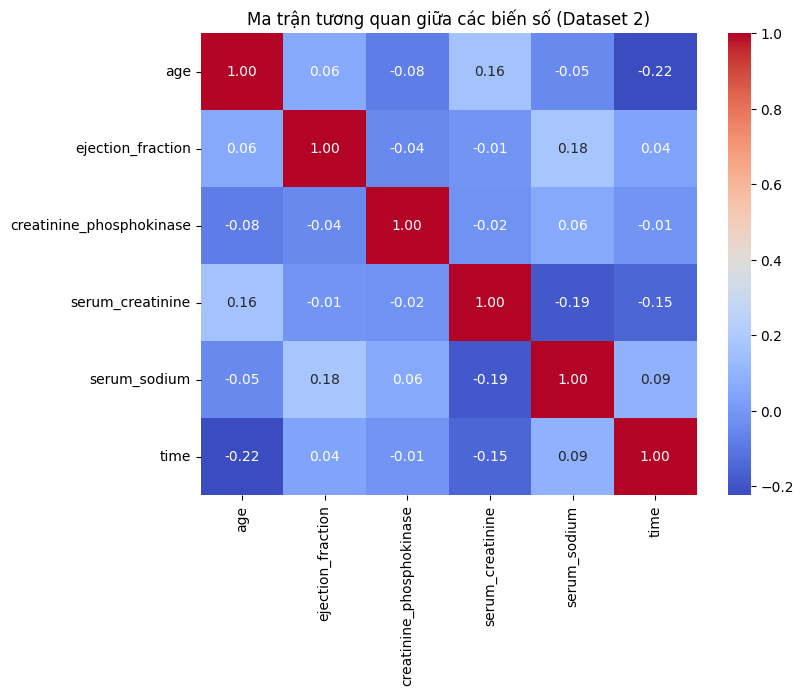


ejection_fraction: giới hạn dưới = 7.50, giới hạn trên = 67.50
Số lượng outlier (trước khi cắt): 2
Số lượng outlier (sau khi cắt): 0

creatinine_phosphokinase: giới hạn dưới = -581.75, giới hạn trên = 1280.25
Số lượng outlier (trước khi cắt): 29
Số lượng outlier (sau khi cắt): 0

serum_creatinine: giới hạn dưới = 0.15, giới hạn trên = 2.15
Số lượng outlier (trước khi cắt): 29
Số lượng outlier (sau khi cắt): 0

serum_sodium: giới hạn dưới = 125.00, giới hạn trên = 149.00
Số lượng outlier (trước khi cắt): 4
Số lượng outlier (sau khi cắt): 0

Hoàn tất xử lý outlier cho Dataset 2.


In [118]:

df_hf = df2.copy() 

print("Tổng quan dữ liệu Dataset 2 (Heart Failure):")
display(df_hf.head())
print(df_hf.describe(include='all'))

# -----------------------------
# 1) Phân bố các biến số quan trọng
# -----------------------------
num_features_hf = ["age", "ejection_fraction", "creatinine_phosphokinase",
                   "serum_creatinine", "serum_sodium", "time"]

for col in num_features_hf:
    if col in df_hf.columns:            
        plt.figure(figsize=(6, 4))
        sns.histplot(df_hf[col], kde=True, bins=30)
        plt.title(f"Phân bố của {col}")
        plt.show()

# -----------------------------
# 2) Phân bố nhãn DEATH_EVENT
# -----------------------------
label2 = "DEATH_EVENT" if "DEATH_EVENT" in df_hf.columns else df_hf.columns[-1]

plt.figure(figsize=(4, 4))
sns.countplot(x=df_hf[label2])
plt.title("Phân bố nhãn DEATH_EVENT (0 = sống, 1 = tử vong)")
plt.xlabel(label2)
plt.ylabel("Số lượng bệnh nhân")
plt.show()

print("Số lượng từng lớp (DEATH_EVENT):")
print(df_hf[label2].value_counts())
print("\nTỷ lệ phần trăm từng lớp:")
print(df_hf[label2].value_counts(normalize=True).mul(100).round(2))

# -----------------------------
# 3) Ma trận tương quan giữa các biến số chính
# -----------------------------
cols_for_corr = [c for c in num_features_hf if c in df_hf.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df_hf[cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Ma trận tương quan giữa các biến số (Dataset 2)")
plt.show()

# -----------------------------
# 4) Outlier Handling bằng IQR cho một số biến
# -----------------------------
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{column}: giới hạn dưới = {lower:.2f}, giới hạn trên = {upper:.2f}")
    n_outliers = ((df[column] < lower) | (df[column] > upper)).sum()
    print(f"Số lượng outlier (trước khi cắt): {n_outliers}")

    df[column] = df[column].clip(lower, upper)
    n_outliers_after = ((df[column] < lower) | (df[column] > upper)).sum()
    print(f"Số lượng outlier (sau khi cắt): {n_outliers_after}")

    return df

# Chỉ xử lý outlier cho các biến có phân bố lệch và hay bị cực trị
cols_outlier_hf = ["ejection_fraction", "creatinine_phosphokinase",
                   "serum_creatinine", "serum_sodium"]

for col in cols_outlier_hf:
    if col in df_hf.columns:
        df_hf = cap_outliers_iqr(df_hf, col)

print("\nHoàn tất xử lý outlier cho Dataset 2.")

# Cập nhật ngược lại df2 để các step sau (preprocessing, model) dùng dữ liệu đã làm sạch
df2 = df_hf.copy()


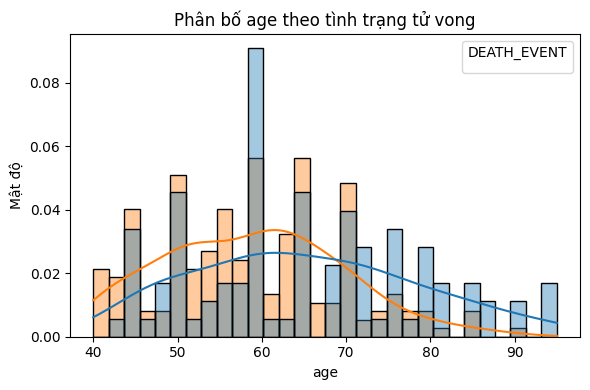

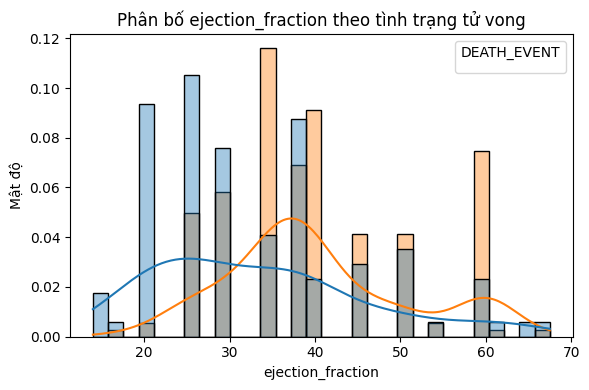

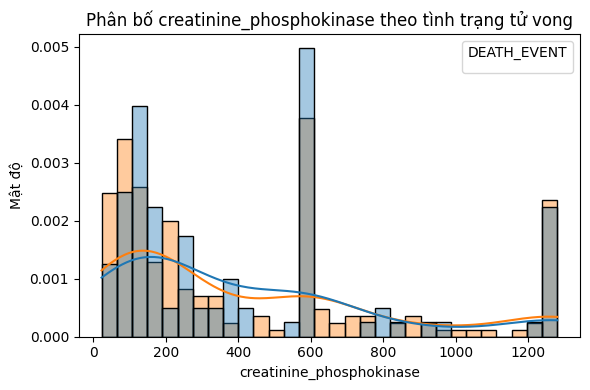

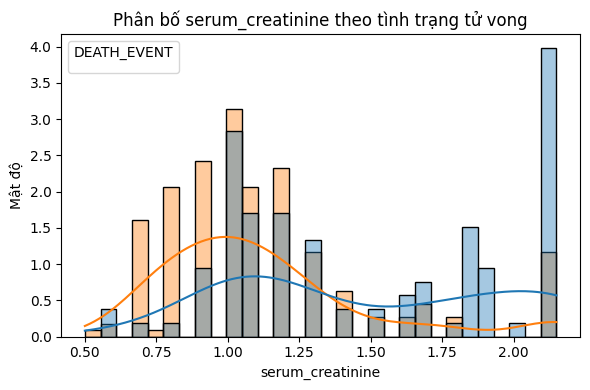

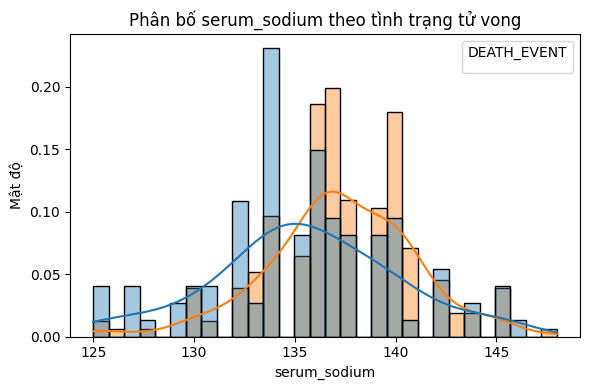

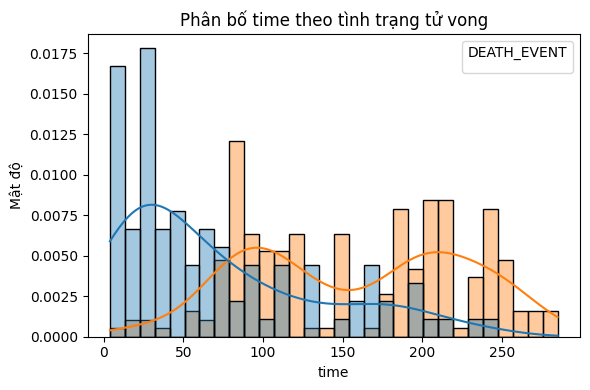

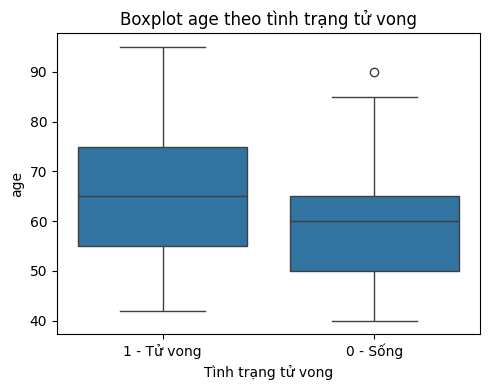

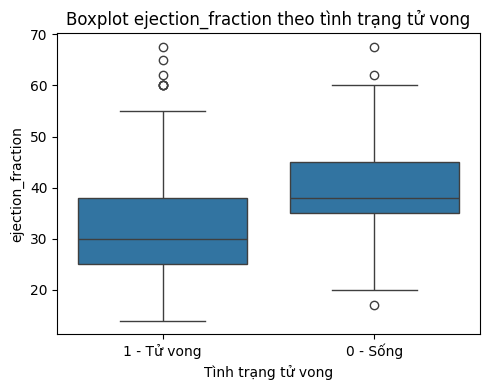

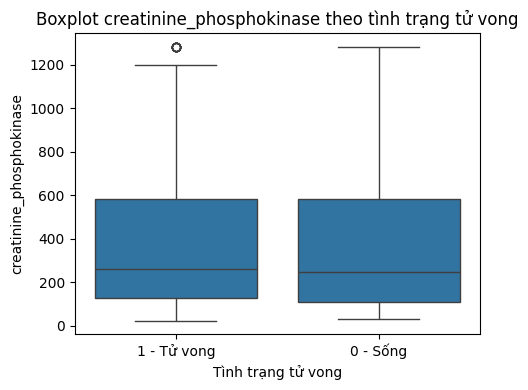

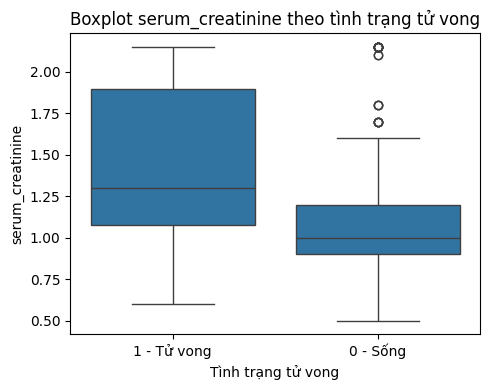

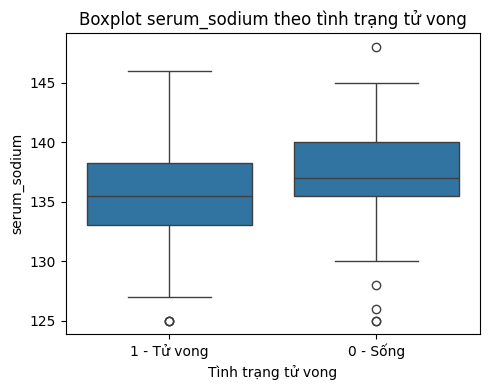

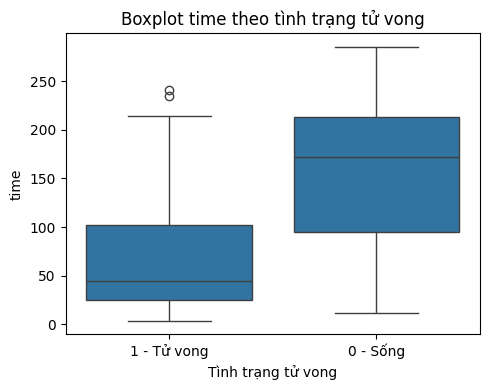

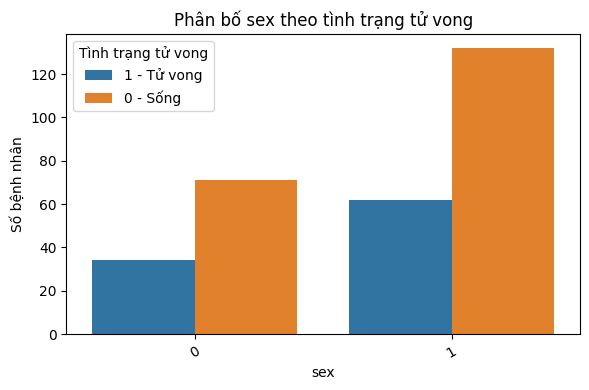

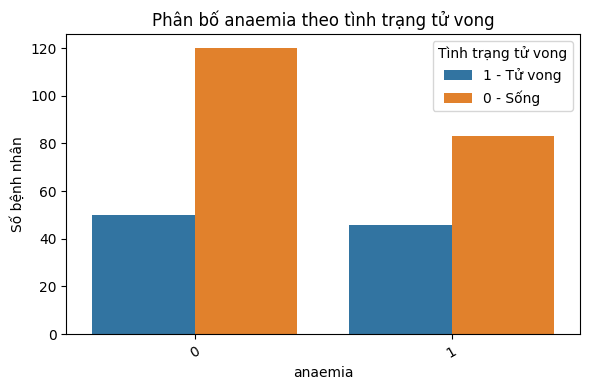

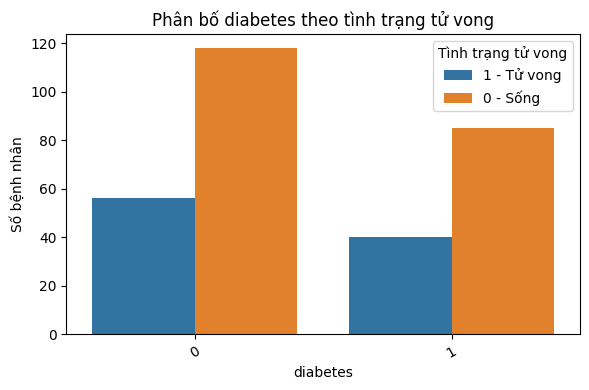

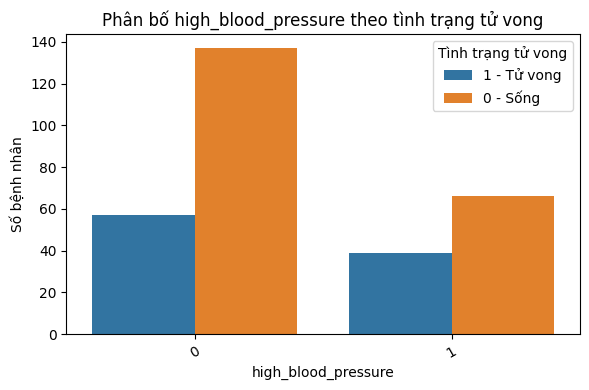

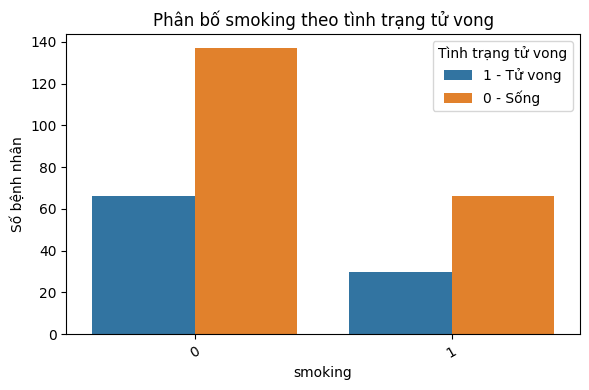


Tỉ lệ DEATH_EVENT theo sex:
     P(sống)  P(tử vong)
sex                     
0       0.68        0.32
1       0.68        0.32

Tỉ lệ DEATH_EVENT theo anaemia:
         P(sống)  P(tử vong)
anaemia                     
0           0.71        0.29
1           0.64        0.36

Tỉ lệ DEATH_EVENT theo diabetes:
          P(sống)  P(tử vong)
diabetes                     
0            0.68        0.32
1            0.68        0.32

Tỉ lệ DEATH_EVENT theo high_blood_pressure:
                     P(sống)  P(tử vong)
high_blood_pressure                     
0                       0.71        0.29
1                       0.63        0.37

Tỉ lệ DEATH_EVENT theo smoking:
         P(sống)  P(tử vong)
smoking                     
0           0.67        0.33
1           0.69        0.31


In [119]:
# ============================================================
# EDA theo nhãn tử vong cho Dataset 2 (Heart Failure)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dùng df_hf (bản đã xử lý outlier). Nếu bạn dùng df2 thì thay df_hf -> df2.
df_hf = df2.copy()

# Xác định tên cột nhãn
label_col = "DEATH_EVENT" if "DEATH_EVENT" in df_hf.columns else df_hf.columns[-1]

# Tạo cột nhãn dạng chữ cho trực quan
df_hf["Death_label"] = df_hf[label_col].map({
    0: "0 - Sống",
    1: "1 - Tử vong"
})

# -----------------------------
# 1) Biến số (numeric) theo nhãn
# -----------------------------
numeric_cols_hf = [
    "age",
    "ejection_fraction",
    "creatinine_phosphokinase",
    "serum_creatinine",
    "serum_sodium",
    "time",
]

numeric_cols_hf = [c for c in numeric_cols_hf if c in df_hf.columns]

# Histogram + KDE theo nhãn
for col in numeric_cols_hf:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_hf,
        x=col,
        hue="Death_label",
        kde=True,
        bins=30,
        stat="density",
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Phân bố {col} theo tình trạng tử vong")
    plt.xlabel(col)
    plt.ylabel("Mật độ")
    plt.legend(title="DEATH_EVENT")
    plt.tight_layout()
    plt.show()

# Boxplot theo nhãn
for col in numeric_cols_hf:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=df_hf,
        x="Death_label",
        y=col
    )
    plt.title(f"Boxplot {col} theo tình trạng tử vong")
    plt.xlabel("Tình trạng tử vong")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 2) Biến phân loại (categorical) theo nhãn
# -----------------------------
categorical_cols_hf = [
    "sex",
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking",
]

categorical_cols_hf = [c for c in categorical_cols_hf if c in df_hf.columns]

# Countplot theo nhãn
for col in categorical_cols_hf:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df_hf,
        x=col,
        hue="Death_label"
    )
    plt.title(f"Phân bố {col} theo tình trạng tử vong")
    plt.xlabel(col)
    plt.ylabel("Số bệnh nhân")
    plt.xticks(rotation=30)
    plt.legend(title="Tình trạng tử vong")
    plt.tight_layout()
    plt.show()

# Bảng tỉ lệ tử vong theo từng nhóm categorical
for col in categorical_cols_hf:
    print(f"\nTỉ lệ DEATH_EVENT theo {col}:")
    ct = pd.crosstab(df_hf[col], df_hf[label_col], normalize="index").round(2)
    ct.columns = ["P(sống)", "P(tử vong)"]
    print(ct)


## Step 2: Tiền xử lý & chia train/val/test cho Dataset 2 (Prognosis)

In [120]:
# ============================================================
# Step 2: Tiền xử lý & chia train/val/test cho Dataset 2 (Prognosis)
# ============================================================

label2 = "DEATH_EVENT" if "DEATH_EVENT" in df2.columns else df2.columns[-1]

X2 = df2.drop(columns=[label2]).copy()
y2 = df2[label2].astype(int)

# Tách numeric / categorical
numeric_cols2 = X2.select_dtypes(include=[np.number]).columns.tolist()
cat_cols2 = [c for c in X2.columns if c not in numeric_cols2]

print("Số feature numeric DS2 :", len(numeric_cols2))
print("Số feature categorical:", len(cat_cols2))

# Preprocessor (dùng chung transformer với DS1)
preprocessor2 = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols2),
    ("cat", categorical_transformer, cat_cols2),
])

# Chia train / temp
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2,
    test_size=0.30,
    stratify=y2,
    random_state=42
)

# Chia temp thành val / test
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp,
    test_size=0.50,
    stratify=y2_temp,
    random_state=42
)

# Kiểm tra nhanh phân bố lớp
def show_split_info(name, y):
    print(f"{name}: n = {len(y)}, tỷ lệ tử vong = {y.mean():.3f}")

print("\nPhân bố tử vong theo từng tập:")
show_split_info("TRAIN", y2_train)
show_split_info("VAL",   y2_val)
show_split_info("TEST",  y2_test)


Số feature numeric DS2 : 12
Số feature categorical: 0

Phân bố tử vong theo từng tập:
TRAIN: n = 209, tỷ lệ tử vong = 0.321
VAL: n = 45, tỷ lệ tử vong = 0.333
TEST: n = 45, tỷ lệ tử vong = 0.311


## Step 3: Huấn luyện & đánh giá mô hình Prognosis

In [121]:
# ============================================================
# Step 3: Huấn luyện & đánh giá mô hình Prognosis 
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score  # dùng trong   
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
import joblib

# ------------------------------------------------------------
# 1) Chuẩn bị: gộp TRAIN + VAL để fit cuối
# ------------------------------------------------------------
X2_train_full = pd.concat([X2_train, X2_val], axis=0)
y2_train_full = pd.concat([y2_train, y2_val], axis=0)

# ------------------------------------------------------------
# 2) Logistic Regression baseline – cross-validation trên TRAIN
# ------------------------------------------------------------
pipe_lr2_base = Pipeline([
    ("pre", preprocessor2),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

cv_lr2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr2 = cross_val_score(
    pipe_lr2_base,
    X2_train,
    y2_train,
    cv=cv_lr2,
    scoring="roc_auc",
    n_jobs=-1
)
mean_auc_lr2 = cv_scores_lr2.mean()
std_auc_lr2 = cv_scores_lr2.std()
print(">>> Logistic Regression – DS2 – CV AUC (mean ± std): "
      f"{mean_auc_lr2:.4f} ± {std_auc_lr2:.4f}")

# ------------------------------------------------------------
# 3) RandomForest cho DS2 – GridSearchCV trên TRAIN
# ------------------------------------------------------------
rf_base_ds2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_rf2 = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.8],
}

cv_rf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf2 = GridSearchCV(
    estimator=rf_base_ds2,
    param_grid=param_grid_rf2,
    cv=cv_rf2,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1
)

print("\n>>> Bắt đầu GridSearchCV cho RandomForest – DS2 (chỉ dùng TRAIN)...")
grid_rf2.fit(X2_train, y2_train)
print(">>> Best params RF – DS2:", grid_rf2.best_params_)
print(">>> Best CV AUC – RF – DS2:", grid_rf2.best_score_)

best_rf2_cv = grid_rf2.best_estimator_
best_auc_rf2 = grid_rf2.best_score_

# ------------------------------------------------------------
# 4) So sánh AUC-CV giữa Logistic Regression và RandomForest (DS2)
# ------------------------------------------------------------
if best_auc_rf2 > mean_auc_lr2:
    print("\n>>> Chọn RandomForest cho DS2 (AUC-CV cao hơn LR).")
    best_model_label_ds2 = "RandomForest"
    best_pipe_ds2 = best_rf2_cv
else:
    print("\n>>> Chọn Logistic Regression cho DS2 (AUC-CV cao hơn hoặc bằng RF).")
    best_model_label_ds2 = "LogisticRegression"
    best_pipe_ds2 = pipe_lr2_base

# ------------------------------------------------------------
# 5) Fit lại mô hình đã chọn trên TRAIN ST
# ------------------------------------------------------------
best_pipe_ds2.fit(X2_train, y2_train)
print("\n>>> Đã fit mô hình đã chọn cho DS2 trên TRAIN (để tune threshold và evaluate).")




>>> Logistic Regression – DS2 – CV AUC (mean ± std): 0.8590 ± 0.0659

>>> Bắt đầu GridSearchCV cho RandomForest – DS2 (chỉ dùng TRAIN)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
>>> Best params RF – DS2: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
>>> Best CV AUC – RF – DS2: 0.9160084988902722

>>> Chọn RandomForest cho DS2 (AUC-CV cao hơn LR).

>>> Đã fit mô hình đã chọn cho DS2 trên TRAIN (để tune threshold và evaluate).


## Step 4: Chọn threshold tối ưu trên validation + đánh giá test (DS2)

In [122]:
# ============================================================
# Step 4: Chọn threshold tối ưu trên validation + đánh giá test (DS2)
# ============================================================

# 1) Tối ưu threshold trên VALIDATION cho DS2
y2_val_proba = best_pipe_ds2.predict_proba(X2_val)[:, 1]


best_th_ds2, table_th_ds2 = tune_threshold_on_validation(
    y2_val,
    y2_val_proba,
    metric="f1",      
    min_recall=None
)

print("\n>>> Best threshold DS2 (tìm trên VALIDATION):", best_th_ds2)
display(table_th_ds2.head())

# 2) Đánh giá trên TEST với threshold mặc định 0.5 (baseline)
y2_test_proba = best_pipe_ds2.predict_proba(X2_test)[:, 1]

metrics_ds2_default = evaluate_at_threshold(
    y2_test,
    y2_test_proba,
    threshold=0.5,
    name=f"{best_model_label_ds2}_DS2 @ threshold=0.5 (baseline test)"
)

# 3) Đánh giá trên TEST với threshold tối ưu (final)
metrics_ds2_tuned = evaluate_at_threshold(
    y2_test,
    y2_test_proba,
    threshold=best_th_ds2,
    name=f"{best_model_label_ds2}_DS2 @ tuned_threshold (final test)"
)

final_pipe_ds2 = clone(best_pipe_ds2)
final_pipe_ds2.fit(X2_train_full, y2_train_full)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path_ds2 = MODEL_DIR / ("best_ds2_" + best_model_label_ds2 + ".pkl")
joblib.dump(final_pipe_ds2, best_model_path_ds2)
print(f"Đã lưu mô hình tốt nhất DS2 (train+val) vào: {best_model_path_ds2}")



>>> Best threshold DS2 (tìm trên VALIDATION): 0.42999999999999994


,threshold,precision,recall,f1,score_used
0,0.05,0.348837,1.0,0.517241,0.517241
1,0.06,0.348837,1.0,0.517241,0.517241
2,0.07,0.384615,1.0,0.555556,0.555556
3,0.08,0.384615,1.0,0.555556,0.555556
4,0.09,0.405405,1.0,0.576923,0.576923


=== RandomForest_DS2 @ threshold=0.5 (baseline test) (threshold=0.500) ===
Accuracy            : 0.7778
Precision           : 0.6250
Recall (Sensitivity): 0.7143
Specificity         : 0.8065
Balanced Accuracy   : 0.7604
F1-score            : 0.6667
AUC-ROC             : 0.8756
------------------------------------------------------------
=== RandomForest_DS2 @ tuned_threshold (final test) (threshold=0.430) ===
Accuracy            : 0.7556
Precision           : 0.5789
Recall (Sensitivity): 0.7857
Specificity         : 0.7419
Balanced Accuracy   : 0.7638
F1-score            : 0.6667
AUC-ROC             : 0.8756
------------------------------------------------------------
Đã lưu mô hình tốt nhất DS2 (train+val) vào: data\models\best_ds2_RandomForest.pkl


## Step 5: Calibartion

Brier score – DS2 (càng thấp càng tốt): 0.1324


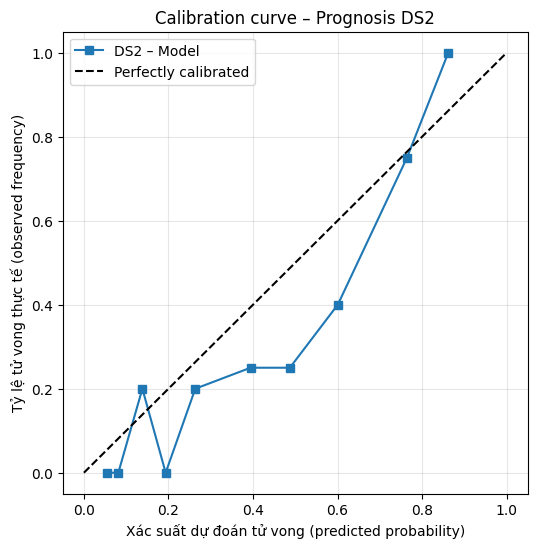

In [123]:
# ============================================================
# Step Y: Calibration cho mô hình Prognosis DS2
# ============================================================

# 1) Xác suất tử vong dự đoán bởi mô hình tốt nhất DS2
y2_proba = y2_test_proba   # xác suất DEATH_EVENT = 1

# 2) Brier Score cho DS2
brier_ds2 = brier_score_loss(y2_test, y2_proba)
print(f"Brier score – DS2 (càng thấp càng tốt): {brier_ds2:.4f}")

# 3) Calibration curve DS2
prob_true2, prob_pred2 = calibration_curve(
    y2_test,
    y2_proba,
    n_bins=10,
    strategy="quantile"
)

# 4) Vẽ Calibration Curve DS2
plt.figure(figsize=(6, 6))
plt.plot(prob_pred2, prob_true2, "s-", label="DS2 – Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Xác suất dự đoán tử vong (predicted probability)")
plt.ylabel("Tỷ lệ tử vong thực tế (observed frequency)")
plt.title("Calibration curve – Prognosis DS2")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()


## Step 6: Vẽ ROC / Confusion / Precision–Recall cho Dataset 2

In [124]:
# ============================================================
# Step 9: Vẽ ROC / Confusion / Precision–Recall cho DS2
# (dùng mô hình tốt nhất đã chọn ở Step 8)
# ============================================================


def plot_roc_ds2(y_true, y_proba, title="ROC Curve – DS2"):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_ds2(y_true, y_pred, title="Confusion Matrix – DS2"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0 (Sống)", "Pred 1 (Tử vong)"],
                yticklabels=["True 0 (Sống)", "True 1 (Tử vong)"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()

    # In thêm các chỉ số y khoa quan trọng
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    balanced_acc = (specificity + sensitivity) / 2

    print(f"Sensitivity (Recall, True Positive Rate) – tử vong: {sensitivity:.4f}")
    print(f"Specificity (True Negative Rate) – sống        : {specificity:.4f}")
    print(f"Balanced Accuracy                              : {balanced_acc:.4f}")

def plot_precision_recall_ds2(y_true, y_proba, title="Precision–Recall – DS2"):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recalls, precisions)

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall (tỷ lệ bắt đúng tử vong)")
    plt.ylabel("Precision (tỷ lệ dự đoán tử vong đúng)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.show()

# ------------------------------------------------
# Dùng kết quả từ mô hình tốt nhất (res_best2)
# ------------------------------------------------

y2_test_proba_best = y2_test_proba
y2_test_pred_best  = (y2_test_proba_best >= best_th_ds2).astype(int)

# Nhãn mô hình (tiếng Việt) cho DS2
model_label_ds2_vn = best_model_label_ds2


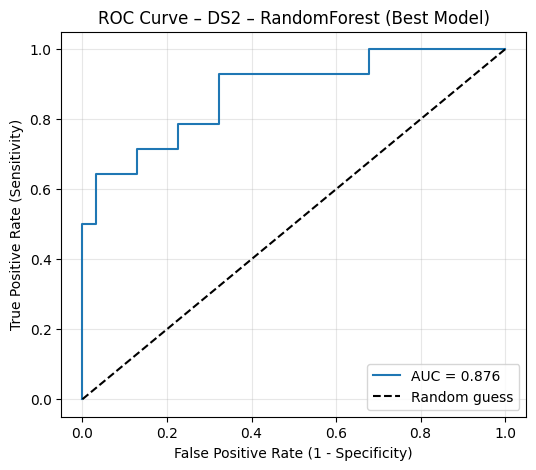

In [125]:
plot_roc_ds2(
    y2_test,
    y2_test_proba_best,
    title=f"ROC Curve – DS2 – {model_label_ds2_vn} (Best Model)"
)

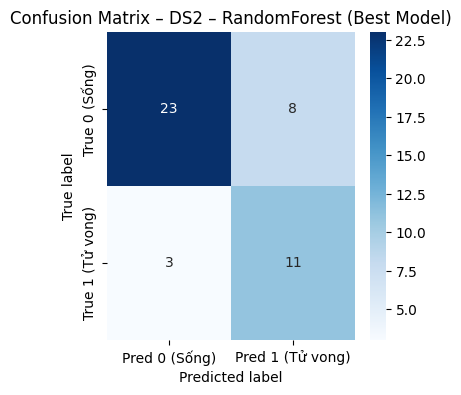

Sensitivity (Recall, True Positive Rate) – tử vong: 0.7857
Specificity (True Negative Rate) – sống        : 0.7419
Balanced Accuracy                              : 0.7638


In [126]:
plot_confusion_ds2(
    y2_test,
    y2_test_pred_best,
    title=f"Confusion Matrix – DS2 – {model_label_ds2_vn} (Best Model)"
)

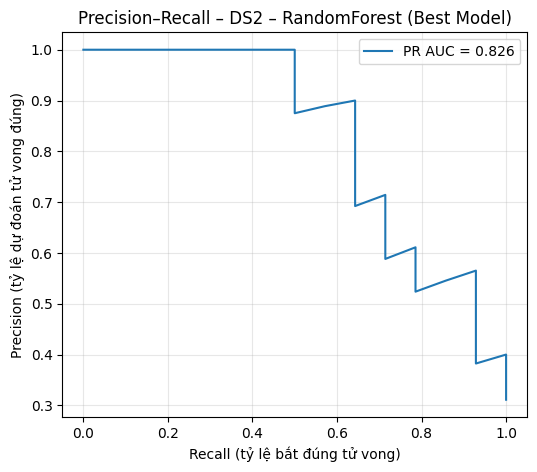

In [127]:
plot_precision_recall_ds2(
    y2_test,
    y2_test_proba_best,
    title=f"Precision–Recall – DS2 – {model_label_ds2_vn} (Best Model)"
)


## Step 7 : Giải thích mô hình Prognosis: Feature Importance & SHAP (Dataset 2)

Tổng số feature DS2: 12

Top 10 features DS2:


time                        0.279263
ejection_fraction           0.015438
serum_creatinine            0.013710
serum_sodium                0.011406
age                         0.002189
platelets                   0.001728
creatinine_phosphokinase    0.001728
diabetes                   -0.001613
sex                        -0.001959
smoking                    -0.002995
dtype: float64

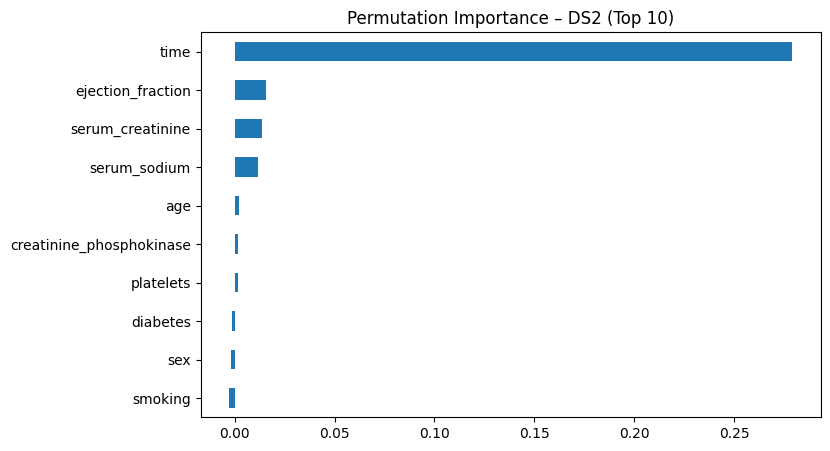

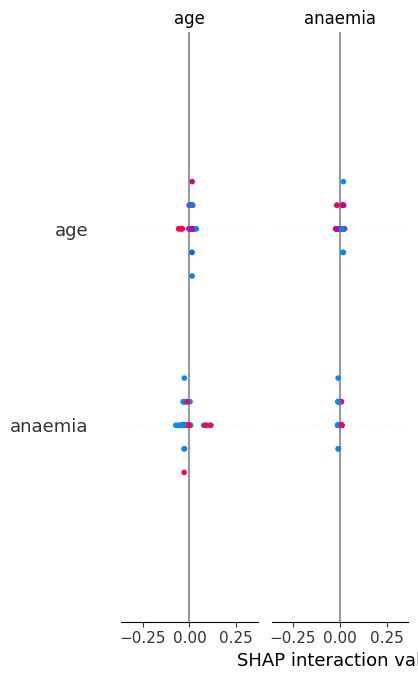

In [128]:
# ============================================================
# Step: Feature Importance + SHAP for DS2
# ============================================================

pre2 = best_pipe_ds2.named_steps['pre']
clf2 = best_pipe_ds2.named_steps['clf']

# ---- 1) Lấy tên feature đúng thứ tự ----
feature_names2 = []

feature_names2.extend(numeric_cols2)

try:
    ohe2 = pre2.named_transformers_['cat'].named_steps['onehot']
    ohe_feature_names2 = ohe2.get_feature_names_out(cat_cols2)
    feature_names2.extend(list(ohe_feature_names2))
except:
    feature_names2.extend(cat_cols2)

print("Tổng số feature DS2:", len(feature_names2))

# ---- 2) Transform test set ----
X2_test_trans = pre2.transform(X2_test)

# ---- 3) PERMUTATION IMPORTANCE ----
try:
    r2 = permutation_importance(
    clf2,
    X2_test_trans,
    y2_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)
    fi2 = pd.Series(r2.importances_mean, index=feature_names2).sort_values(ascending=False)

    print("\nTop 10 features DS2:")
    display(fi2.head(10))

    plt.figure(figsize=(8,5))
    fi2.head(10).sort_values().plot(kind="barh")
    plt.title("Permutation Importance – DS2 (Top 10)")
    plt.show()
except Exception as e:
    print("Permutation importance failed DS2:", e)

# ---- 4) SHAP ----
try:
    import shap
    
    if hasattr(clf2, "feature_importances_"):   # RandomForest
        explainer2 = shap.TreeExplainer(clf2)
        shap_vals2 = explainer2.shap_values(X2_test_trans)

        if isinstance(shap_vals2, list):
            shap_vals2 = shap_vals2[1]

        shap.summary_plot(shap_vals2, X2_test_trans, feature_names=feature_names2)

    else:   # Logistic Regression
        explainer2 = shap.LinearExplainer(clf2, X2_test_trans)
        shap_vals2 = explainer2.shap_values(X2_test_trans)

        shap.summary_plot(shap_vals2, X2_test_trans, feature_names=feature_names2)

except Exception as e:
    print("SHAP DS2 failed:", e)


## Step 8: Đánh giá fairness theo giới tính

In [130]:
# ============================================================
# Step F: ĐÁNH GIÁ FAIRNESS cho mô hình Prognosis DS2
#   - Chỉ theo 2 thuộc tính: sex và age_group
# ============================================================

from sklearn.metrics import confusion_matrix, accuracy_score

# ------------------------------------------------------------
# 1) Chọn cột giới tính và tạo cột nhóm tuổi
# ------------------------------------------------------------

fairness_cols = []

# 1.1. Giới tính (sex)
sex_candidates = [c for c in df2.columns if "sex" in c.lower()]
if sex_candidates:
    sex_col = sex_candidates[0]
    fairness_cols.append(sex_col)
    print(f"[*] Sử dụng cột giới tính cho fairness: {sex_col}")
else:
    sex_col = None
    print("[-] Không tìm thấy cột giới tính (sex) trong df2.")

# 1.2. Nhóm tuổi (age_group) từ cột age
if "age" in df2.columns:
    if "age_group" not in df2.columns:
        df2["age_group"] = pd.cut(
            df2["age"],
            bins=[0, 60, 75, 150],      # bạn có thể chỉnh lại ngưỡng nếu muốn
            labels=["<60", "60–75", ">75"],
            right=True,
            include_lowest=True,
        )
    fairness_cols.append("age_group")
    print("[*] Tạo cột age_group để đánh giá fairness theo nhóm tuổi.")
else:
    print("[-] Không có cột age trong df2, bỏ qua fairness theo nhóm tuổi.")

if not fairness_cols:
    print("\nKHÔNG có cột nào để đánh giá fairness cho DS2.")
else:
    print("\nCác cột sẽ dùng để đánh giá fairness DS2:", fairness_cols)

# ------------------------------------------------------------
# 2) Xác suất và dự đoán trên TEST cho 2 threshold
# ------------------------------------------------------------

# Dùng mô hình best_pipe_ds2 (đã fit trên TRAIN, threshold tune trên VAL)
y2_test_proba_best = best_pipe_ds2.predict_proba(X2_test)[:, 1]
y2_test_pred_05 = (y2_test_proba_best >= 0.5).astype(int)
y2_test_pred_tuned = (y2_test_proba_best >= best_th_ds2).astype(int)

# ------------------------------------------------------------
# 3) Hàm tính fairness cho 1 cột nhóm (sex hoặc age_group)
# ------------------------------------------------------------

def compute_fairness_for_group(df_eval, group_col, pred_col, th_label):
    """
    df_eval  : DataFrame chứa y_true, y_pred_xxx và cột group_col.
    group_col: tên cột nhóm (vd: 'sex', 'age_group').
    pred_col : tên cột dự đoán (vd: 'y_pred_05', 'y_pred_tuned').
    th_label : mô tả threshold (vd: '0.50 (baseline)', '0.23 (tuned)').
    """
    results = []
    for group, data in df_eval.groupby(group_col):
        cm = confusion_matrix(data["y_true"], data[pred_col], labels=[0, 1])

        # Đảm bảo luôn có đủ 4 phần tử (tn, fp, fn, tp)
        if cm.shape == (1, 1):
            # Chỉ có 1 lớp xuất hiện trong group này
            if data["y_true"].unique()[0] == 0:
                tn, fp, fn, tp = cm[0, 0], 0, 0, 0
            else:
                tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
        else:
            tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Recall
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        balanced_acc = (sensitivity + specificity) / 2

        results.append({
            "Group col": group_col,
            "Group": group,
            "Threshold": th_label,
            "N": len(data),
            "Accuracy": accuracy_score(data["y_true"], data[pred_col]),
            "Positive Rate (Pred=1)": data[pred_col].mean(),
            "Recall (Sensitivity)": sensitivity,
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "Balanced Accuracy": balanced_acc,
        })

    return pd.DataFrame(results)

# ------------------------------------------------------------
# 4) Tạo df_eval trên TEST, gắn cột sex & age_group
# ------------------------------------------------------------

df2_eval = pd.DataFrame(index=X2_test.index)
df2_eval["y_true"] = y2_test.values
df2_eval["y_pred_05"] = y2_test_pred_05
df2_eval["y_pred_tuned"] = y2_test_pred_tuned

# gắn sex, age_group từ df2 gốc
for col in fairness_cols:
    df2_eval[col] = df2.loc[X2_test.index, col]

# ------------------------------------------------------------
# 5) Tính fairness cho từng cột group (sex, age_group) và từng threshold
# ------------------------------------------------------------

all_fairness_tables = []

for group_col in fairness_cols:
    # threshold 0.5
    fair_05 = compute_fairness_for_group(
        df2_eval, group_col, "y_pred_05", "0.50 (baseline)"
    )
    # threshold tuned
    fair_tuned = compute_fairness_for_group(
        df2_eval, group_col, "y_pred_tuned", f"{best_th_ds2:.2f} (tuned)"
    )

    fairness_compare = pd.concat([fair_05, fair_tuned], ignore_index=True)
    all_fairness_tables.append(fairness_compare)

    print(f"\n=== FAIRNESS DS2 theo nhóm '{group_col}' ===")
    display(fairness_compare)

# Tổng hợp lại nếu cần
if all_fairness_tables:
    fairness_all_ds2 = pd.concat(all_fairness_tables, ignore_index=True)
    print("\n=== TỔNG HỢP FAIRNESS DS2 (sex + age_group) ===")
    display(fairness_all_ds2)


[*] Sử dụng cột giới tính cho fairness: sex
[*] Tạo cột age_group để đánh giá fairness theo nhóm tuổi.

Các cột sẽ dùng để đánh giá fairness DS2: ['sex', 'age_group']

=== FAIRNESS DS2 theo nhóm 'sex' ===


,Group col,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
0,sex,0,0.50 (baseline),16,0.687500,0.312500,0.500000,0.800000,0.200000,0.500000,0.650000
1,sex,1,0.50 (baseline),29,0.827586,0.379310,0.875000,0.809524,0.190476,0.125000,0.842262
2,sex,0,0.43 (tuned),16,0.750000,0.375000,0.666667,0.800000,0.200000,0.333333,0.733333
3,sex,1,0.43 (tuned),29,0.758621,0.448276,0.875000,0.714286,0.285714,0.125000,0.794643



=== FAIRNESS DS2 theo nhóm 'age_group' ===


,Group col,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
0,age_group,<60,0.50 (baseline),29,0.827586,0.275862,0.714286,0.863636,0.136364,0.285714,0.788961
1,age_group,60–75,0.50 (baseline),11,0.818182,0.363636,0.750000,0.857143,0.142857,0.250000,0.803571
2,age_group,>75,0.50 (baseline),5,0.400000,0.800000,0.666667,0.000000,1.000000,0.333333,0.333333
3,age_group,<60,0.43 (tuned),29,0.793103,0.379310,0.857143,0.772727,0.227273,0.142857,0.814935
4,age_group,60–75,0.43 (tuned),11,0.818182,0.363636,0.750000,0.857143,0.142857,0.250000,0.803571
5,age_group,>75,0.43 (tuned),5,0.400000,0.800000,0.666667,0.000000,1.000000,0.333333,0.333333



=== TỔNG HỢP FAIRNESS DS2 (sex + age_group) ===


,Group col,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
0,sex,0,0.50 (baseline),16,0.687500,0.312500,0.500000,0.800000,0.200000,0.500000,0.650000
1,sex,1,0.50 (baseline),29,0.827586,0.379310,0.875000,0.809524,0.190476,0.125000,0.842262
2,sex,0,0.43 (tuned),16,0.750000,0.375000,0.666667,0.800000,0.200000,0.333333,0.733333
3,sex,1,0.43 (tuned),29,0.758621,0.448276,0.875000,0.714286,0.285714,0.125000,0.794643
4,age_group,<60,0.50 (baseline),29,0.827586,0.275862,0.714286,0.863636,0.136364,0.285714,0.788961
5,age_group,60–75,0.50 (baseline),11,0.818182,0.363636,0.750000,0.857143,0.142857,0.250000,0.803571
6,age_group,>75,0.50 (baseline),5,0.400000,0.800000,0.666667,0.000000,1.000000,0.333333,0.333333
7,age_group,<60,0.43 (tuned),29,0.793103,0.379310,0.857143,0.772727,0.227273,0.142857,0.814935
8,age_group,60–75,0.43 (tuned),11,0.818182,0.363636,0.750000,0.857143,0.142857,0.250000,0.803571
9,age_group,>75,0.43 (tuned),5,0.400000,0.800000,0.666667,0.000000,1.000000,0.333333,0.333333
